In [1]:
import kagglehub
import os
# Download latest version
path1 = kagglehub.dataset_download("masoudnickparvar/brain-tumor-mri-dataset")

print(os.listdir(path1)) 
BRAIN_IMAGES = os.path.join(path1, "Training")

# Download latest version
path2 = kagglehub.dataset_download("kaustubhdikshit/neu-surface-defect-database")
print("Path to dataset files:", path2)
NEU_IMAGES = os.path.join(path2, "NEU-DET/train/images")

print(NEU_IMAGES)
print(os.listdir(NEU_IMAGES))
# Download latest version
path3 = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")
print("Path to dataset files:", path3)

CHEST_IMAGES = os.path.join(path3, "chest_xray/train")
print(os.listdir(CHEST_IMAGES))
# Download latest version
path4 = kagglehub.dataset_download("apollo2506/eurosat-dataset")
print("Path to dataset files:", path4)

EUROSAT_IMAGES = os.path.join(path4, "EuroSAT")
print(os.listdir(EUROSAT_IMAGES))

['Testing', 'Training']
Path to dataset files: C:\Users\sunda\.cache\kagglehub\datasets\kaustubhdikshit\neu-surface-defect-database\versions\1
C:\Users\sunda\.cache\kagglehub\datasets\kaustubhdikshit\neu-surface-defect-database\versions\1\NEU-DET/train/images
['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'scratches']
Path to dataset files: C:\Users\sunda\.cache\kagglehub\datasets\paultimothymooney\chest-xray-pneumonia\versions\2
['NORMAL', 'PNEUMONIA']
Path to dataset files: C:\Users\sunda\.cache\kagglehub\datasets\apollo2506\eurosat-dataset\versions\6
['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'label_map.json', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake', 'test.csv', 'train.csv', 'validation.csv']


In [3]:
import cv2
import numpy as np
import os
import pandas as pd

from skimage.feature import (
    local_binary_pattern,
    hog
)

from skimage.filters import gabor



# SAME output directory as your GLCM code
OUTPUT_DIR = "glcm_5"

# SAME image size
IMG_SIZE = 128

# SAME maximum number of samples
MAX_SAMPLES = 4000

# SAME random seed
SEED = 42

# Numerical stability
EPS = 1e-10

np.random.seed(SEED)



DATASETS = [

    # {
    #     "name": "ful_bone",
    #     "path": "Dataset"
    # },

    # --------------------------------------------------------
    # BONE
    # --------------------------------------------------------

    # {
    #     "name": "bone",
    #     "path": "clahe_output"
    # },

    # --------------------------------------------------------
    # NEU DEFECT
    # --------------------------------------------------------
    #
    # CHANGE THIS PATH if needed
    #

    # {
    #     "name": "neu_defect",
    #     "path": NEU_IMAGES
    # },

    # --------------------------------------------------------
    # BRAIN MRI
    # --------------------------------------------------------
    #
    # CHANGE THIS PATH if needed
    #

    # {
    #     "name": "brain_mri",
    #     "path": BRAIN_IMAGES
    # },

    # --------------------------------------------------------
    # CHEST X-RAY
    # --------------------------------------------------------
    #
    # CHANGE THIS PATH if needed
    #

    {
        "name": "chest_xray",
        "path": CHEST_IMAGES
    },

    # --------------------------------------------------------
    # EURO-SAT
    # --------------------------------------------------------
    #
    # CHANGE THIS PATH if needed
    #

    {
        "name": "eurosat",
        "path": EUROSAT_IMAGES
    }
]


# ============================================================
# CREATE OUTPUT DIRECTORY
# ============================================================

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)


# ============================================================
# COMMON IMAGE PREPROCESSING
# ============================================================

def preprocess_image(img):

    # --------------------------------------------------------
    # Resize
    # --------------------------------------------------------

    img = cv2.resize(
        img,
        (IMG_SIZE, IMG_SIZE)
    )

    # --------------------------------------------------------
    # Grayscale
    # --------------------------------------------------------

    if len(img.shape) == 3:

        img = cv2.cvtColor(
            img,
            cv2.COLOR_BGR2GRAY
        )

    # --------------------------------------------------------
    # UINT8
    # --------------------------------------------------------

    img = np.asarray(
        img,
        dtype=np.uint8
    )

    # --------------------------------------------------------
    # CLAHE
    #
    # SAME CLAHE SETTINGS AS YOUR GLCM CODE
    # --------------------------------------------------------

    clahe = cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(8, 8)
    )

    img = clahe.apply(img)

    return img


# ============================================================
# LBP FEATURE EXTRACTION
# ============================================================

def extract_lbp_features(img):

    # --------------------------------------------------------
    # Preprocess
    # --------------------------------------------------------

    img = preprocess_image(
        img
    )


    P = 8
    R = 1

    # --------------------------------------------------------
    # Calculate LBP
    # --------------------------------------------------------

    lbp = local_binary_pattern(
        img,
        P,
        R,
        method="uniform"
    )

    # --------------------------------------------------------
    # Histogram
    # --------------------------------------------------------

    n_bins = P + 2

    hist, _ = np.histogram(
        lbp.ravel(),
        bins=np.arange(
            0,
            n_bins + 1
        ),
        range=(
            0,
            n_bins
        )
    )

    # --------------------------------------------------------
    # Convert to float
    # --------------------------------------------------------

    hist = hist.astype(
        np.float64
    )

    # --------------------------------------------------------
    # Normalize histogram
    # --------------------------------------------------------

    hist /= (
        hist.sum() + EPS
    )

    return hist


def extract_gabor_features(img):

    # --------------------------------------------------------
    # Preprocess
    # --------------------------------------------------------

    img = preprocess_image(
        img
    )

    # --------------------------------------------------------
    # Convert to float
    # --------------------------------------------------------

    img = img.astype(
        np.float64
    )

    # --------------------------------------------------------
    # Normalize 0-1
    # --------------------------------------------------------

    img /= 255.0

    # --------------------------------------------------------
    # GABOR PARAMETERS
    # --------------------------------------------------------
    #
    # 4 frequencies
    # 4 orientations
    #
    # For every filter:
    #
    #   Mean
    #   Standard deviation
    #   Energy
    #
    # Total:
    #
    #   4 x 4 x 3 = 48 features
    #

    FREQUENCIES = [
        0.1,
        0.2,
        0.3,
        0.4
    ]

    THETAS = [
        0,
        np.pi / 4,
        np.pi / 2,
        3 * np.pi / 4
    ]

    # --------------------------------------------------------
    # Feature storage
    # --------------------------------------------------------

    features = []

    # --------------------------------------------------------
    # Apply Gabor filters
    # --------------------------------------------------------

    for frequency in FREQUENCIES:

        for theta in THETAS:

            # ------------------------------------------------
            # Gabor filter
            # ------------------------------------------------

            real, imag = gabor(
                img,
                frequency=frequency,
                theta=theta
            )

            # ------------------------------------------------
            # Magnitude
            # ------------------------------------------------

            magnitude = np.sqrt(
                real ** 2 +
                imag ** 2
            )

            # ------------------------------------------------
            # Mean
            # ------------------------------------------------

            mean_value = np.mean(
                magnitude
            )

            # ------------------------------------------------
            # Standard deviation
            # ------------------------------------------------

            std_value = np.std(
                magnitude
            )

            # ------------------------------------------------
            # Energy
            # ------------------------------------------------

            energy_value = np.mean(
                magnitude ** 2
            )

            # ------------------------------------------------
            # Store
            # ------------------------------------------------

            features.extend([
                mean_value,
                std_value,
                energy_value
            ])

    return np.asarray(
        features,
        dtype=np.float64
    )


# ============================================================
# HOG FEATURE EXTRACTION
# ============================================================

def extract_hog_features(img):

    # --------------------------------------------------------
    # Preprocess
    # --------------------------------------------------------

    img = preprocess_image(
        img
    )

    # --------------------------------------------------------
    # HOG
    # --------------------------------------------------------
    #
    # Same 128x128 input for every dataset.
    #
    # orientations = 9
    # pixels_per_cell = 8x8
    # cells_per_block = 2x2
    #

    features = hog(
        img,
        orientations=9,
        pixels_per_cell=(
            8,
            8
        ),
        cells_per_block=(
            2,
            2
        ),
        block_norm="L2-Hys",
        feature_vector=True
    )

    return np.asarray(
        features,
        dtype=np.float64
    )


# ============================================================
# FIND DATASET CLASSES
# ============================================================

def get_class_directories(
    dataset_path
):

    if not os.path.exists(
        dataset_path
    ):

        raise FileNotFoundError(
            f"Dataset not found: "
            f"{dataset_path}"
        )

    class_dirs = [

        d

        for d in sorted(
            os.listdir(
                dataset_path
            )
        )

        if os.path.isdir(
            os.path.join(
                dataset_path,
                d
            )
        )
    ]

    if len(class_dirs) == 0:

        raise ValueError(
            f"No class folders found in "
            f"{dataset_path}"
        )

    return class_dirs


# ============================================================
# LOAD BALANCED DATASET
# ============================================================

def load_dataset(
    dataset_path
):

    # --------------------------------------------------------
    # Find classes
    # --------------------------------------------------------

    class_dirs = get_class_directories(
        dataset_path
    )

    n_classes = len(
        class_dirs
    )

    # --------------------------------------------------------
    # Balanced sample count
    #
    # SAME LOGIC AS YOUR GLCM CODE
    # --------------------------------------------------------

    samples_per_class = (
        MAX_SAMPLES //
        n_classes
    )

    print(
        f"\nNumber of classes: "
        f"{n_classes}"
    )

    print(
        f"Maximum samples: "
        f"{MAX_SAMPLES}"
    )

    print(
        f"Samples per class: "
        f"{samples_per_class}"
    )

    # --------------------------------------------------------
    # Store image paths + labels
    # --------------------------------------------------------

    image_data = []

    # --------------------------------------------------------
    # Read every class
    # --------------------------------------------------------

    for class_name in class_dirs:

        class_path = os.path.join(
            dataset_path,
            class_name
        )

        class_files = []

        # ----------------------------------------------------
        # Find images
        # ----------------------------------------------------

        for img_name in os.listdir(
            class_path
        ):

            if not img_name.lower().endswith(
                (
                    ".jpg",
                    ".jpeg",
                    ".png",
                    ".bmp",
                    ".tif",
                    ".tiff"
                )
            ):

                continue

            img_path = os.path.join(
                class_path,
                img_name
            )

            class_files.append(
                img_path
            )

        # ----------------------------------------------------
        # Shuffle
        # ----------------------------------------------------

        np.random.shuffle(
            class_files
        )

        # ----------------------------------------------------
        # Balanced selection
        # ----------------------------------------------------

        selected = class_files[
            :samples_per_class
        ]

        print(
            f"{class_name}: "
            f"{len(selected)} images"
        )

        # ----------------------------------------------------
        # Store
        # ----------------------------------------------------

        for img_path in selected:

            image_data.append(
                (
                    img_path,
                    class_name
                )
            )

    # --------------------------------------------------------
    # Final shuffle
    # --------------------------------------------------------

    np.random.shuffle(
        image_data
    )

    # --------------------------------------------------------
    # Load images
    # --------------------------------------------------------

    images = []

    labels = []

    for img_path, label in image_data:

        img = cv2.imread(
            img_path,
            cv2.IMREAD_GRAYSCALE
        )

        if img is not None:

            images.append(
                img
            )

            labels.append(
                label
            )

        else:

            print(
                f"WARNING: Could not read "
                f"{img_path}"
            )

    # --------------------------------------------------------
    # Print loaded count
    # --------------------------------------------------------

    print(
        f"\nSuccessfully loaded: "
        f"{len(images)} images"
    )

    return (
        images,
        labels
    )


# ============================================================
# PROCESS ONE DATASET
# ============================================================

def process_dataset(
    images,
    labels,
    dataset_name
):

    # --------------------------------------------------------
    # Feature storage
    # --------------------------------------------------------

    lbp_list = []

    gabor_list = []

    hog_list = []

    # --------------------------------------------------------
    # Total
    # --------------------------------------------------------

    total = len(
        images
    )

    print(
        "\n" + "=" * 70
    )

    print(
        f"EXTRACTING LBP + GABOR + HOG"
    )

    print(
        f"Dataset: {dataset_name}"
    )

    print(
        f"Total images: {total}"
    )

    print(
        "=" * 70
    )

    # --------------------------------------------------------
    # Process images
    # --------------------------------------------------------

    for i, (img, label) in enumerate(
        zip(images, labels)
    ):

        try:

            # ================================================
            # LBP
            # ================================================

            lbp_features = extract_lbp_features(
                img
            )

            # ================================================
            # GABOR
            # ================================================

            gabor_features = extract_gabor_features(
                img
            )

            # ================================================
            # HOG
            # ================================================

            hog_features = extract_hog_features(
                img
            )

            # ================================================
            # Store
            # ================================================

            lbp_list.append(
                lbp_features
            )

            gabor_list.append(
                gabor_features
            )

            hog_list.append(
                hog_features
            )

        except Exception as e:

            print(
                f"ERROR image {i}: {e}"
            )

            continue

        # ----------------------------------------------------
        # Progress
        # ----------------------------------------------------

        if (i + 1) % 100 == 0:

            print(
                f"{i + 1}/{total} "
                f"images processed"
            )

    # --------------------------------------------------------
    # Convert to arrays
    # --------------------------------------------------------

    lbp_array = np.asarray(
        lbp_list,
        dtype=np.float64
    )

    gabor_array = np.asarray(
        gabor_list,
        dtype=np.float64
    )

    hog_array = np.asarray(
        hog_list,
        dtype=np.float64
    )

    # --------------------------------------------------------
    # IMPORTANT
    #
    # If an image fails, the number of features can be smaller
    # than the original labels.
    #
    # Normally there should be no failures.
    # This check prevents CSV mismatch.
    # --------------------------------------------------------

    valid_count = len(
        lbp_array
    )

    if valid_count != len(labels):

        print(
            "\nWARNING:"
        )

        print(
            f"Expected labels: {len(labels)}"
        )

        print(
            f"Successfully extracted: "
            f"{valid_count}"
        )

        # Since errors are unlikely, stop instead of creating
        # an incorrect CSV.

        raise ValueError(
            "Feature count does not match label count."
        )

    # --------------------------------------------------------
    # Save
    # --------------------------------------------------------

    save_csv_files(
        lbp_array,
        gabor_array,
        hog_array,
        labels,
        dataset_name
    )


# ============================================================
# SAVE CSV FILES
# ============================================================

def save_csv_files(
    lbp_array,
    gabor_array,
    hog_array,
    labels,
    dataset_name
):

    # --------------------------------------------------------
    # SAME DATASET DIRECTORY AS GLCM
    # --------------------------------------------------------

    dataset_dir = os.path.join(
        OUTPUT_DIR,
        dataset_name
    )

    os.makedirs(
        dataset_dir,
        exist_ok=True
    )

    # ========================================================
    # LBP CSV
    # ========================================================

    lbp_df = pd.DataFrame(
        lbp_array
    )

    lbp_df.columns = [

        f"lbp_{i + 1}"

        for i in range(
            lbp_df.shape[1]
        )
    ]

    lbp_df["label"] = labels

    lbp_path = os.path.join(
        dataset_dir,
        "lbp.csv"
    )

    lbp_df.to_csv(
        lbp_path,
        index=False
    )

    # ========================================================
    # GABOR CSV
    # ========================================================

    gabor_df = pd.DataFrame(
        gabor_array
    )

    gabor_df.columns = [

        f"gabor_{i + 1}"

        for i in range(
            gabor_df.shape[1]
        )
    ]

    gabor_df["label"] = labels

    gabor_path = os.path.join(
        dataset_dir,
        "gabor.csv"
    )

    gabor_df.to_csv(
        gabor_path,
        index=False
    )

    # ========================================================
    # HOG CSV
    # ========================================================

    hog_df = pd.DataFrame(
        hog_array
    )

    hog_df.columns = [

        f"hog_{i + 1}"

        for i in range(
            hog_df.shape[1]
        )
    ]

    hog_df["label"] = labels

    hog_path = os.path.join(
        dataset_dir,
        "hog.csv"
    )

    hog_df.to_csv(
        hog_path,
        index=False
    )

    # ========================================================
    # PRINT RESULTS
    # ========================================================

    print(
        "\n" + "=" * 70
    )

    print(
        f"FEATURE CSV FILES SAVED"
    )

    print(
        f"Dataset: {dataset_name}"
    )

    print(
        "=" * 70
    )

    print(
        f"\nLBP:"
    )

    print(
        f"  {lbp_path}"
    )

    print(
        f"  Shape = {lbp_df.shape}"
    )

    print(
        f"\nGabor:"
    )

    print(
        f"  {gabor_path}"
    )

    print(
        f"  Shape = {gabor_df.shape}"
    )

    print(
        f"\nHOG:"
    )

    print(
        f"  {hog_path}"
    )

    print(
        f"  Shape = {hog_df.shape}"
    )


# ============================================================
# PROCESS FOLDER DATASET
# ============================================================

def process_folder_dataset(
    dataset
):

    dataset_path = dataset["path"]

    dataset_name = dataset["name"]

    # --------------------------------------------------------
    # Header
    # --------------------------------------------------------

    print(
        "\n" + "=" * 70
    )

    print(
        f"Processing dataset: "
        f"{dataset_name}"
    )

    print(
        f"Path: "
        f"{dataset_path}"
    )

    print(
        "=" * 70
    )

    # --------------------------------------------------------
    # Load balanced images
    # --------------------------------------------------------

    images, labels = load_dataset(
        dataset_path
    )

    # --------------------------------------------------------
    # Extract LBP + Gabor + HOG
    # --------------------------------------------------------

    process_dataset(
        images,
        labels,
        dataset_name
    )


# ============================================================
# RUN ALL DATASETS
# ============================================================

def run_all_datasets():

    print(
        "\n" + "=" * 80
    )

    print(
        "LBP + GABOR + HOG FEATURE EXTRACTION"
    )

    print(
        "=" * 80
    )

    # --------------------------------------------------------
    # Process every dataset
    # --------------------------------------------------------

    for dataset in DATASETS:

        process_folder_dataset(
            dataset
        )

    # --------------------------------------------------------
    # Final summary
    # --------------------------------------------------------

    print(
        "\n" + "=" * 80
    )

    print(
        "ALL LBP + GABOR + HOG DATASETS COMPLETE"
    )

    print(
        "=" * 80
    )

    print(
        "\nGenerated files:"
    )

    for dataset in DATASETS:

        name = dataset["name"]

        print(
            f"\n{name}/"
        )

        print(
            f"  {OUTPUT_DIR}/"
            f"{name}/lbp.csv"
        )

        print(
            f"  {OUTPUT_DIR}/"
            f"{name}/gabor.csv"
        )

        print(
            f"  {OUTPUT_DIR}/"
            f"{name}/hog.csv"
        )

    print(
        "\n" + "=" * 80
    )


# ============================================================
# MAIN
# ============================================================

if __name__ == "__main__":

    run_all_datasets()


LBP + GABOR + HOG FEATURE EXTRACTION

Processing dataset: chest_xray
Path: C:\Users\sunda\.cache\kagglehub\datasets\paultimothymooney\chest-xray-pneumonia\versions\2\chest_xray/train

Number of classes: 2
Maximum samples: 4000
Samples per class: 2000
NORMAL: 1341 images
PNEUMONIA: 2000 images

Successfully loaded: 3341 images

EXTRACTING LBP + GABOR + HOG
Dataset: chest_xray
Total images: 3341
100/3341 images processed
200/3341 images processed
300/3341 images processed
400/3341 images processed
500/3341 images processed
600/3341 images processed
700/3341 images processed
800/3341 images processed
900/3341 images processed
1000/3341 images processed
1100/3341 images processed
1200/3341 images processed
1300/3341 images processed
1400/3341 images processed
1500/3341 images processed
1600/3341 images processed
1700/3341 images processed
1800/3341 images processed
1900/3341 images processed
2000/3341 images processed
2100/3341 images processed
2200/3341 images processed
2300/3341 images 


DEVICE: cpu


DETECTED DATASETS AND CSV FILES

bone:
    dmvtd           -> glcm_5\bone\dmvtd.csv
    gabor           -> glcm_5\bone\gabor.csv
    hog             -> glcm_5\bone\hog.csv
    hybrid          -> glcm_5\bone\hybrid.csv
    lbp             -> glcm_5\bone\lbp.csv
    normal          -> glcm_5\bone\normal.csv

brain_mri:
    dmvtd           -> glcm_5\brain_mri\dmvtd.csv
    gabor           -> glcm_5\brain_mri\gabor.csv
    hog             -> glcm_5\brain_mri\hog.csv
    hybrid          -> glcm_5\brain_mri\hybrid.csv
    lbp             -> glcm_5\brain_mri\lbp.csv
    normal          -> glcm_5\brain_mri\normal.csv

chest_xray:
    dmvtd           -> glcm_5\chest_xray\dmvtd.csv
    gabor           -> glcm_5\chest_xray\gabor.csv
    hog             -> glcm_5\chest_xray\hog.csv
    hybrid          -> glcm_5\chest_xray\hybrid.csv
    lbp             -> glcm_5\chest_xray\lbp.csv
    normal          -> glcm_5\chest_xray\normal.csv

eurosat:
    dmvtd           -> glcm_5\eurosat\dmv

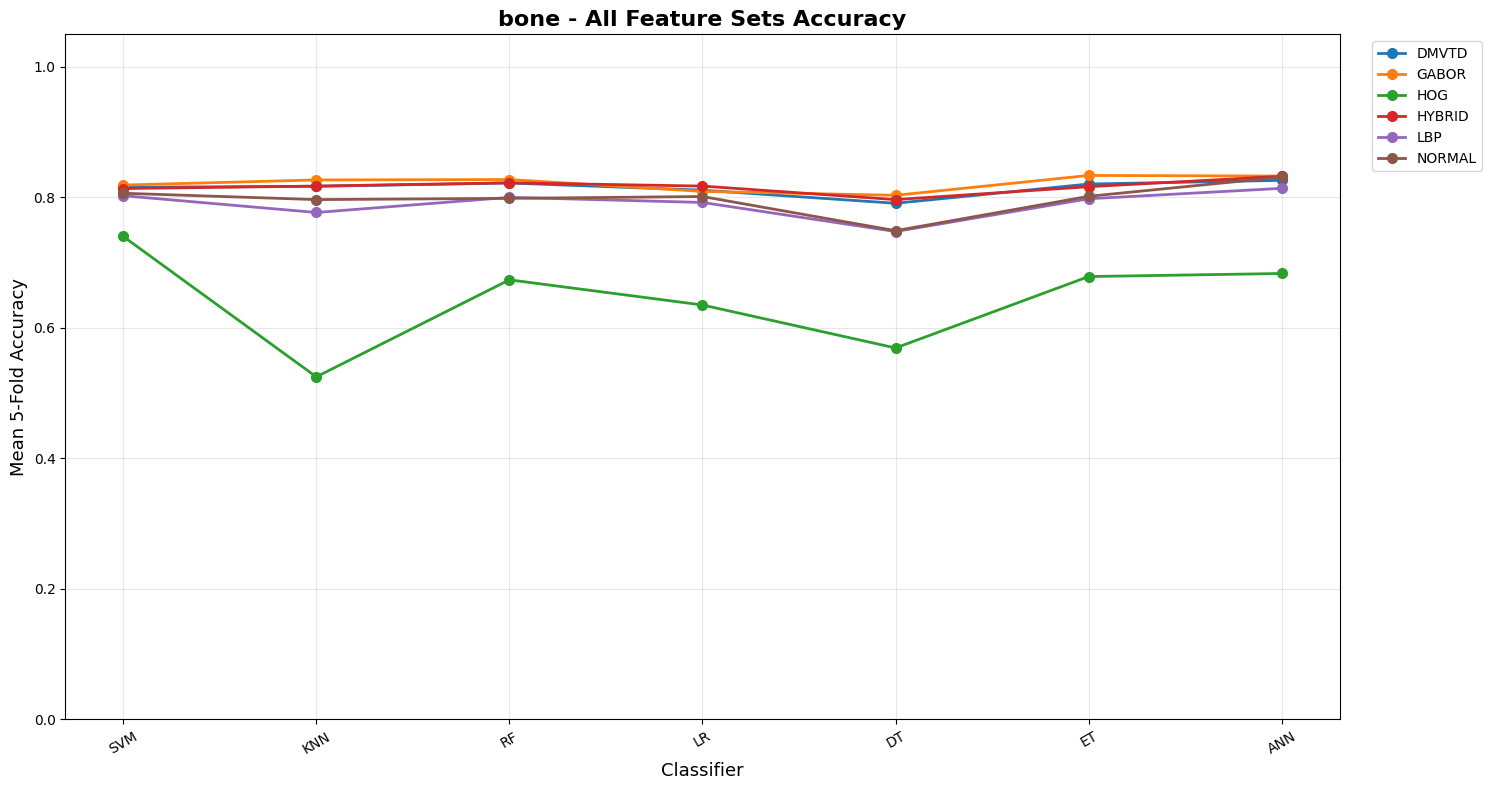


Saved plot: accuracy_plots\brain_mri_all_features.png


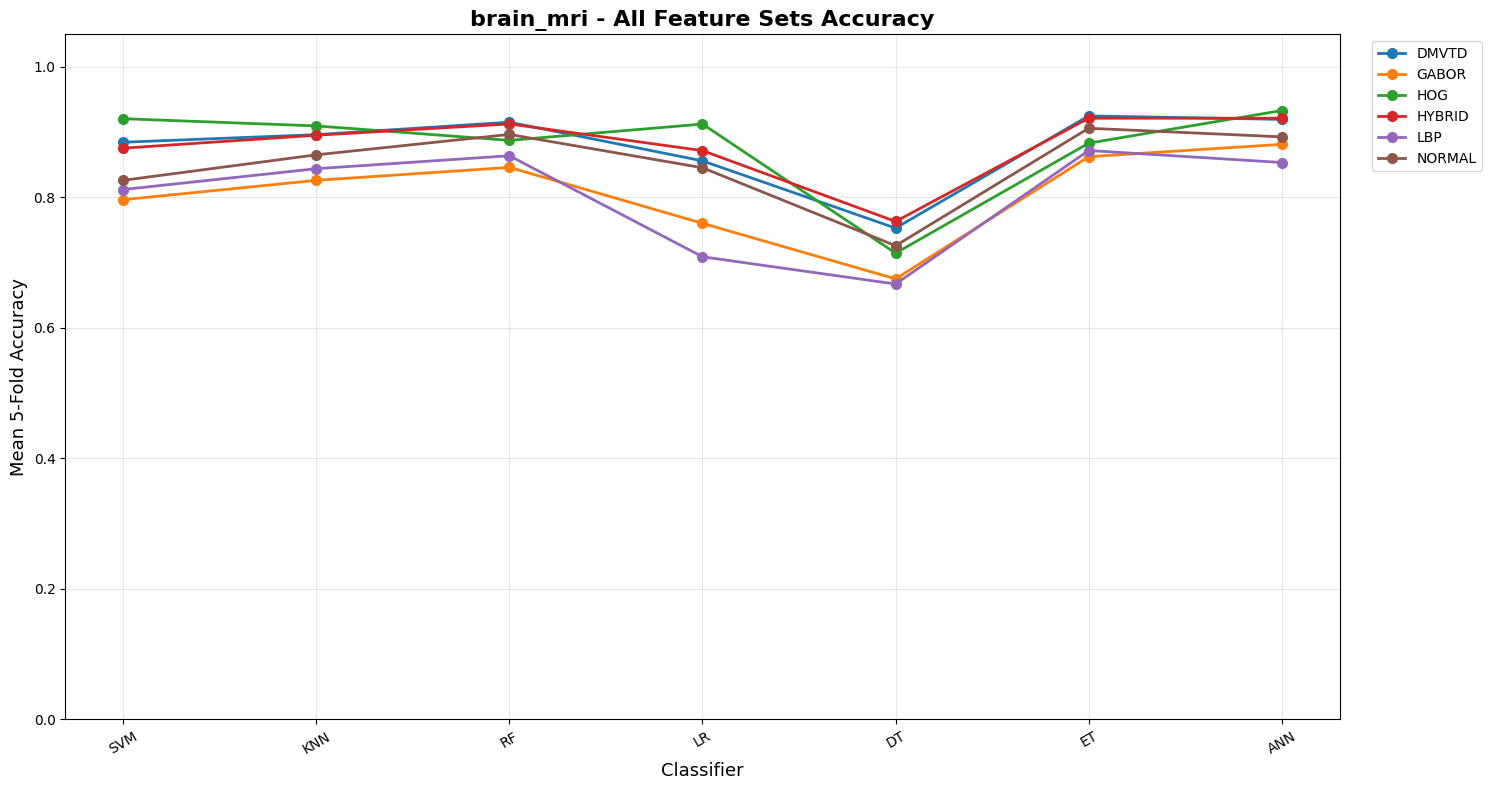


Saved plot: accuracy_plots\chest_xray_all_features.png


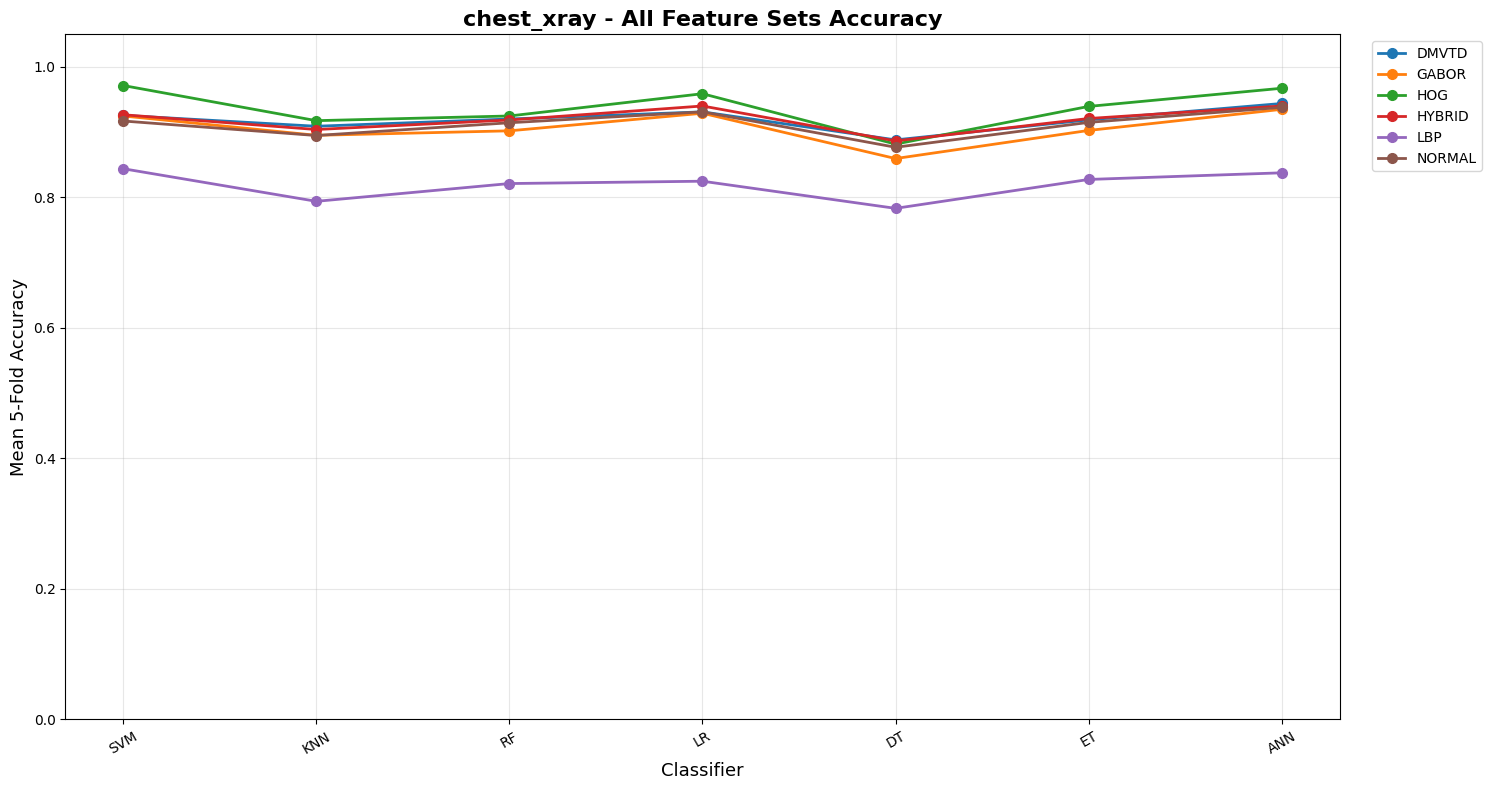


Saved plot: accuracy_plots\eurosat_all_features.png


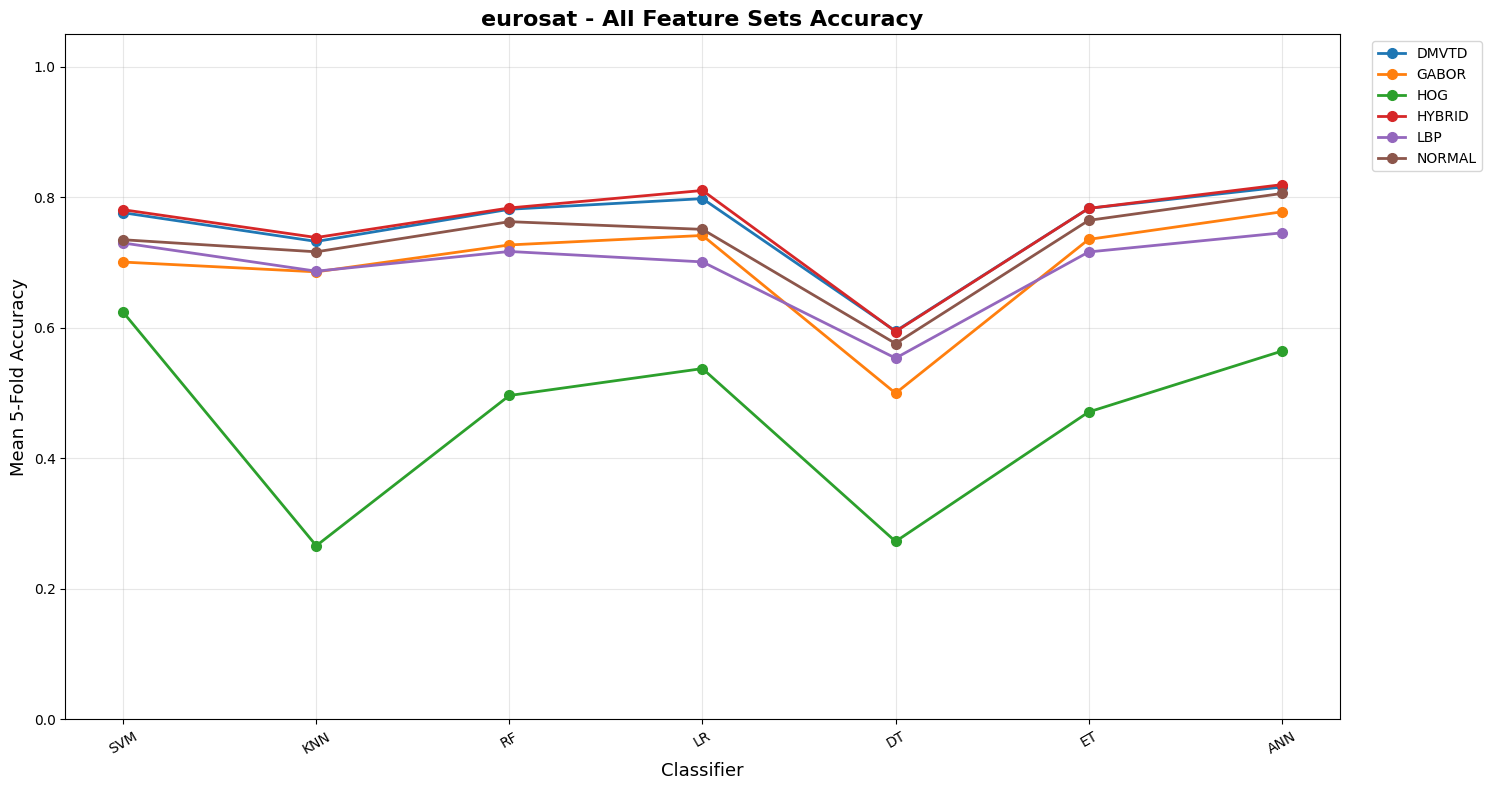


Saved plot: accuracy_plots\ful_bone_all_features.png


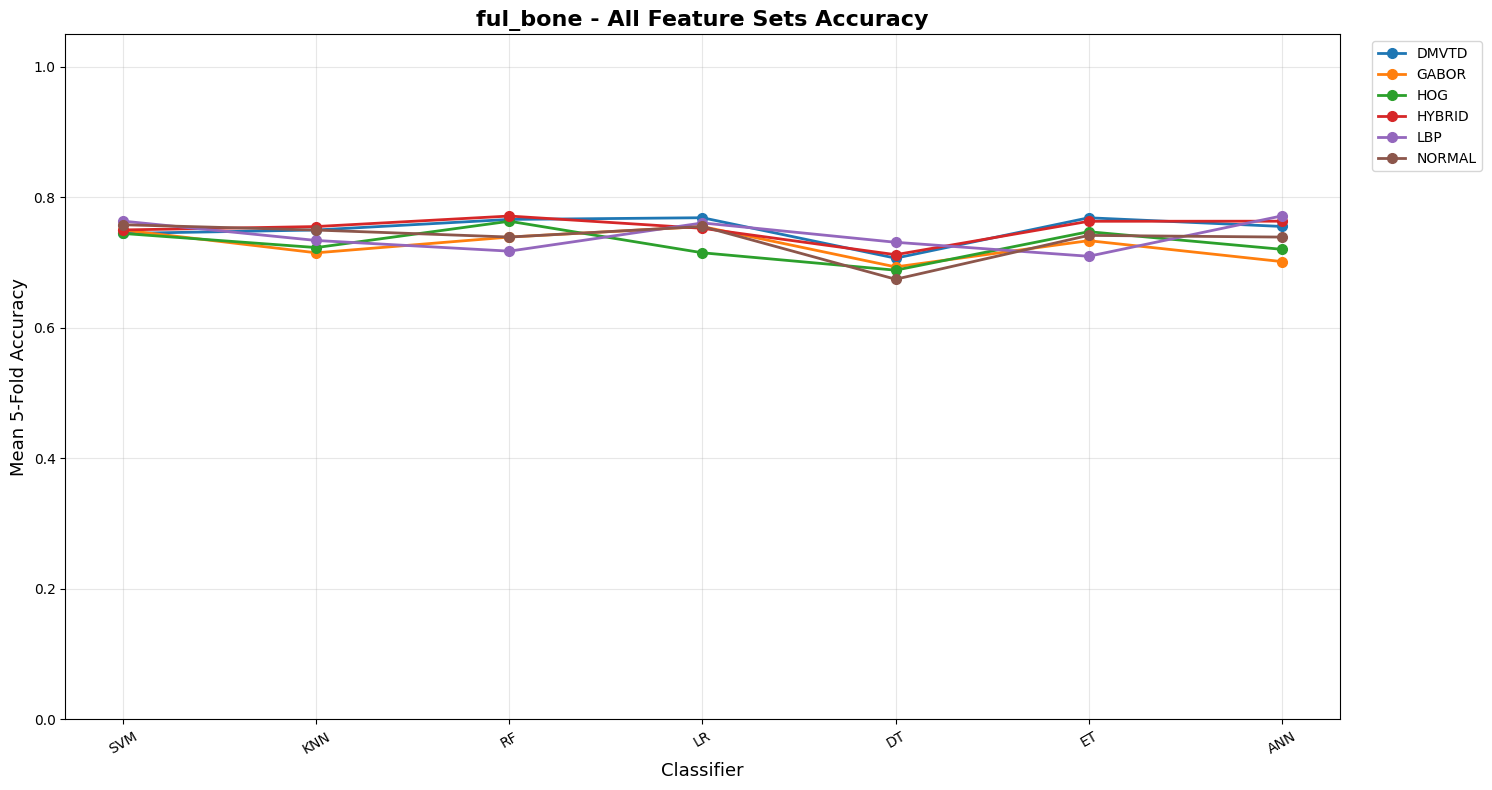


Saved plot: accuracy_plots\neu_defect_all_features.png


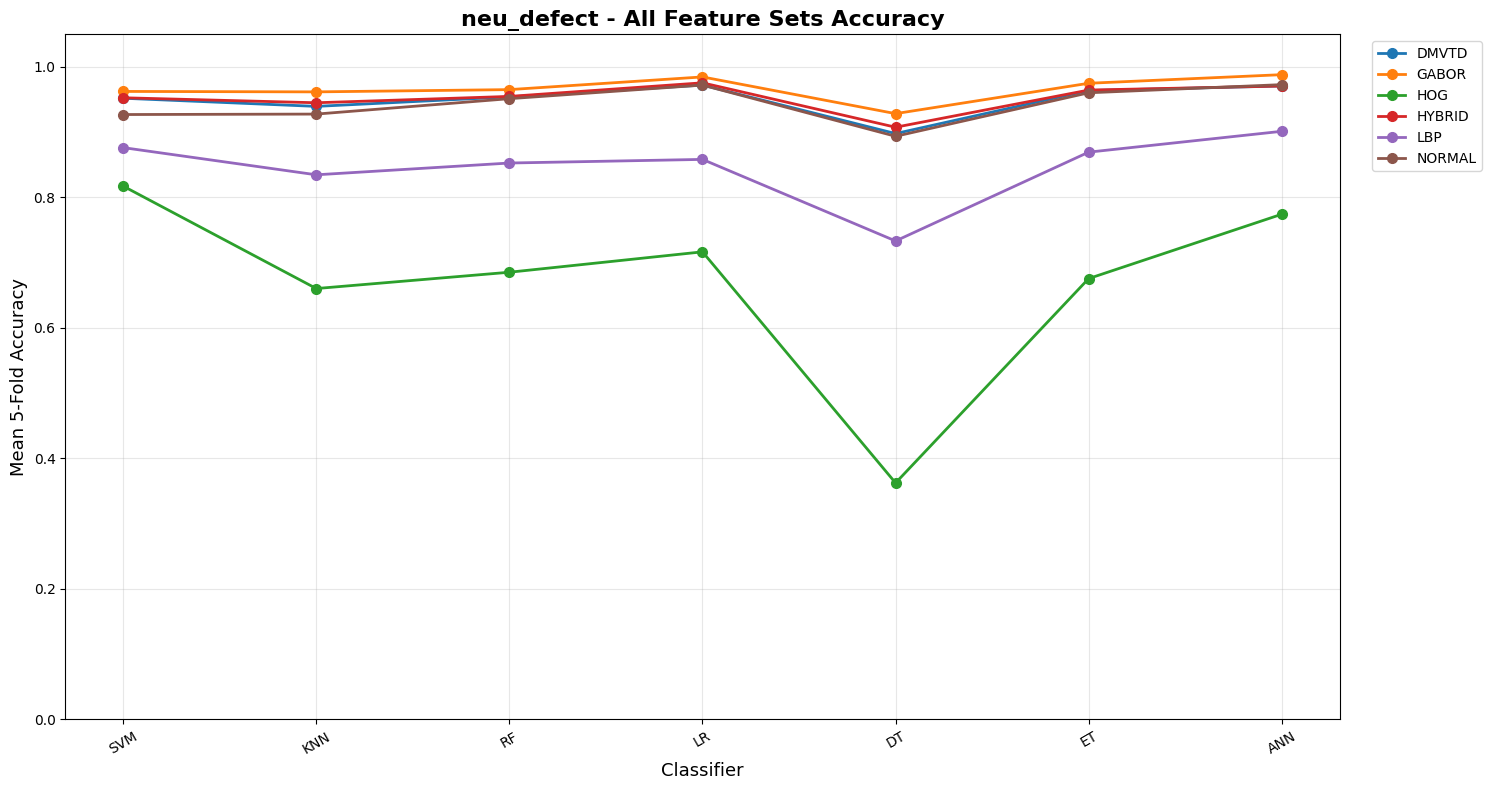



PLOTTING EACH FEATURE ACROSS ALL DATASETS

Features found:
  - dmvtd
  - gabor
  - hog
  - hybrid
  - lbp
  - normal
Saved plot: accuracy_plots\all_datasets_dmvtd.png


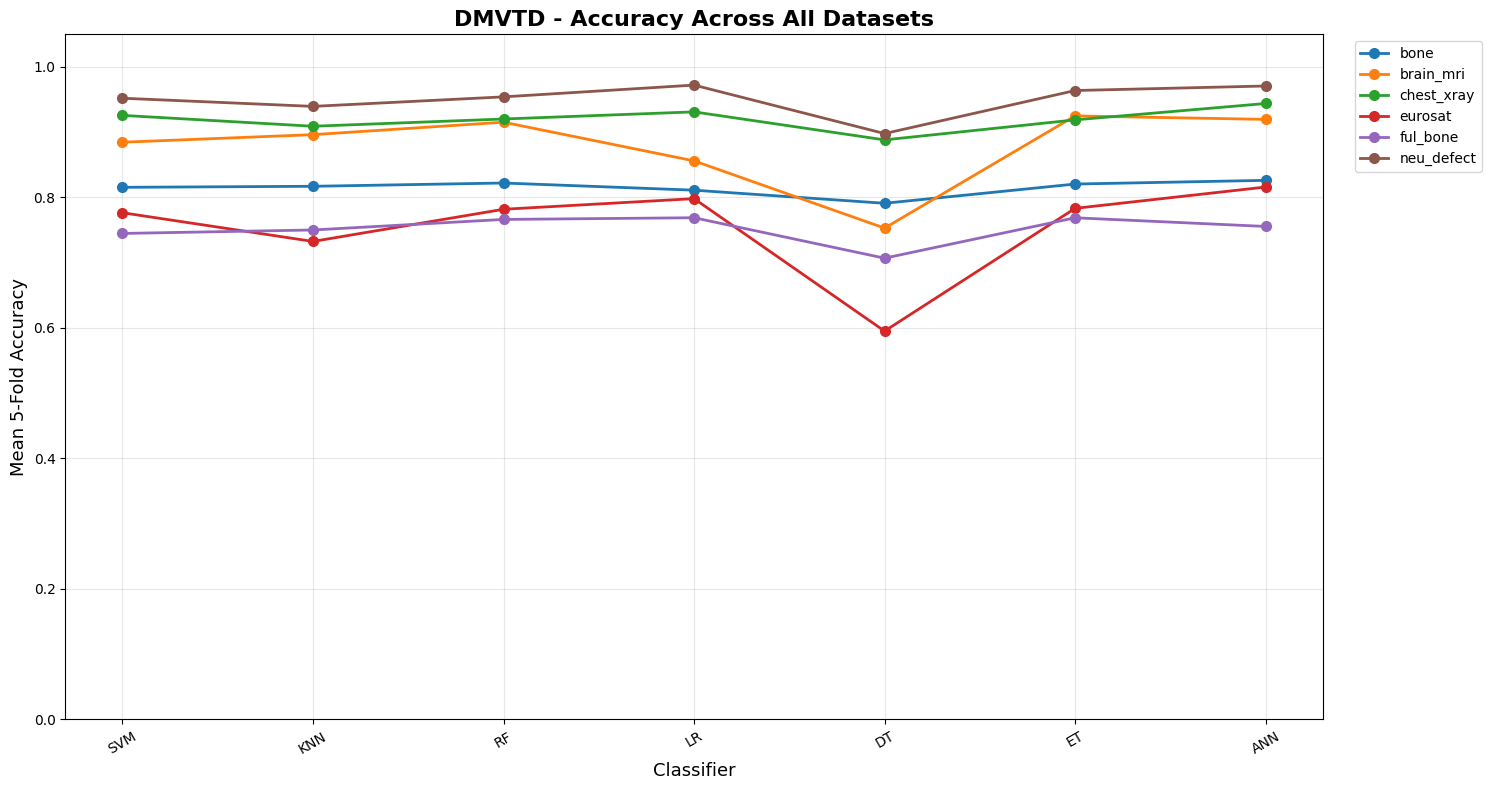

Saved plot: accuracy_plots\all_datasets_gabor.png


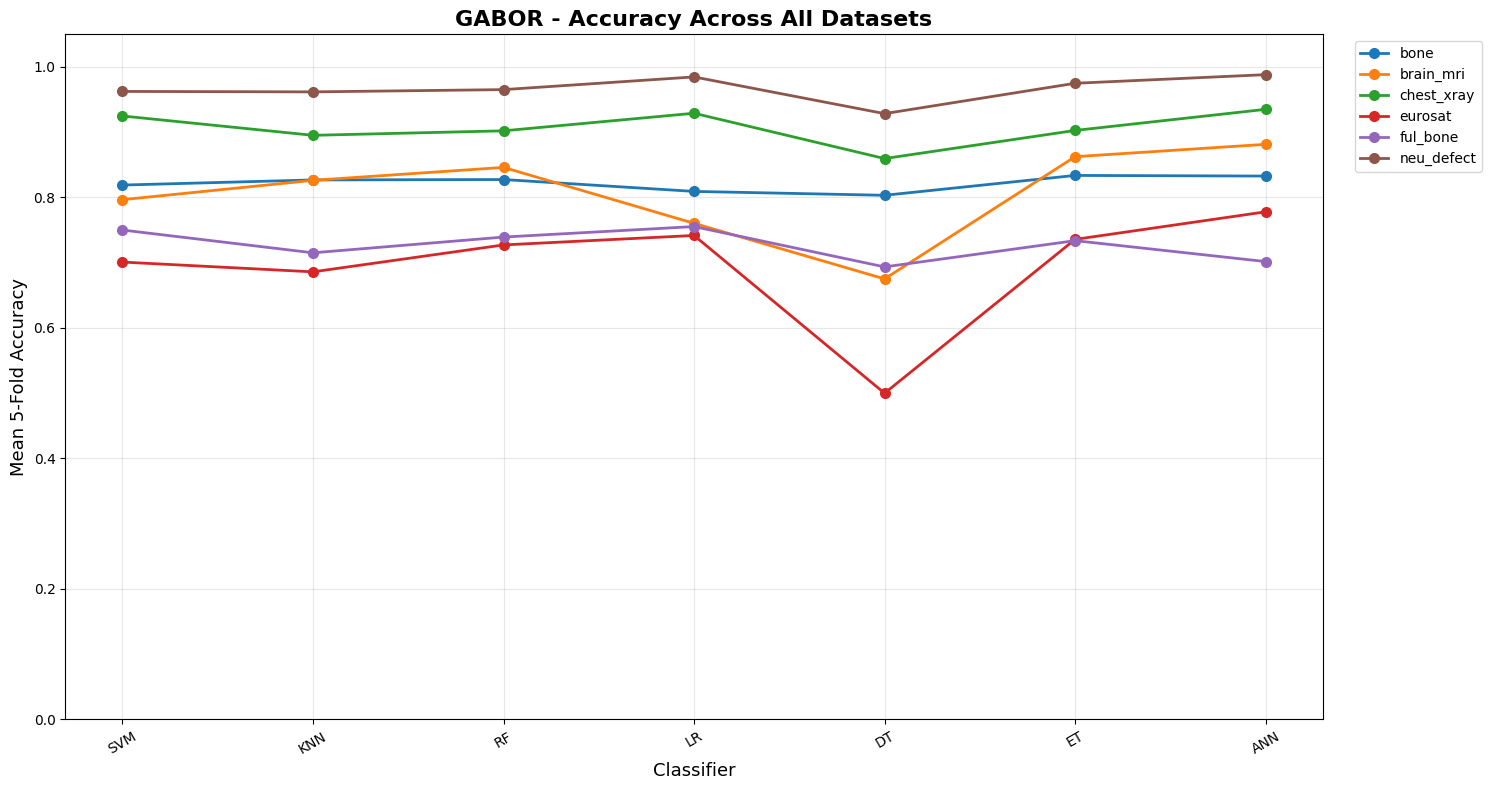

Saved plot: accuracy_plots\all_datasets_hog.png


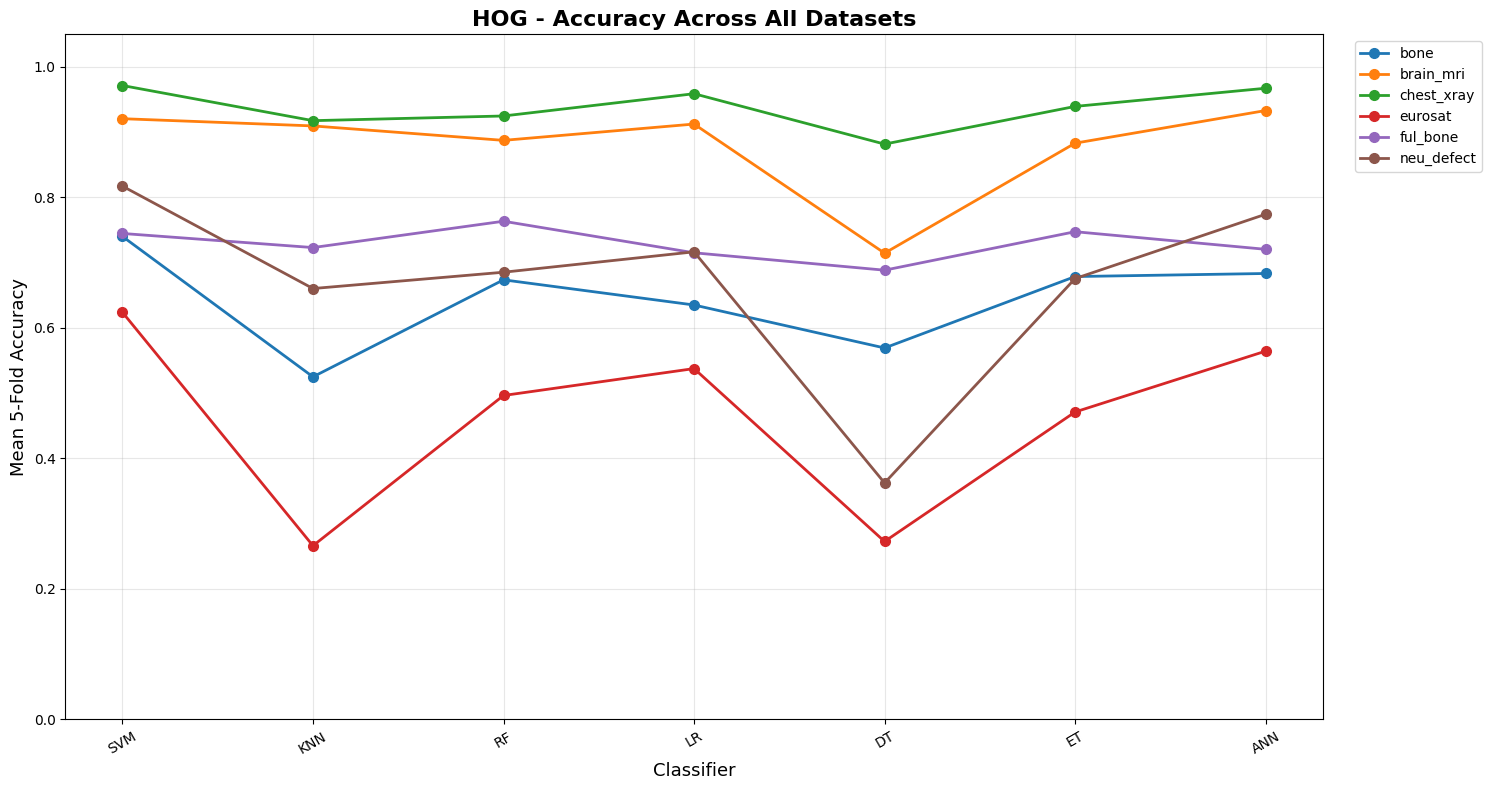

Saved plot: accuracy_plots\all_datasets_hybrid.png


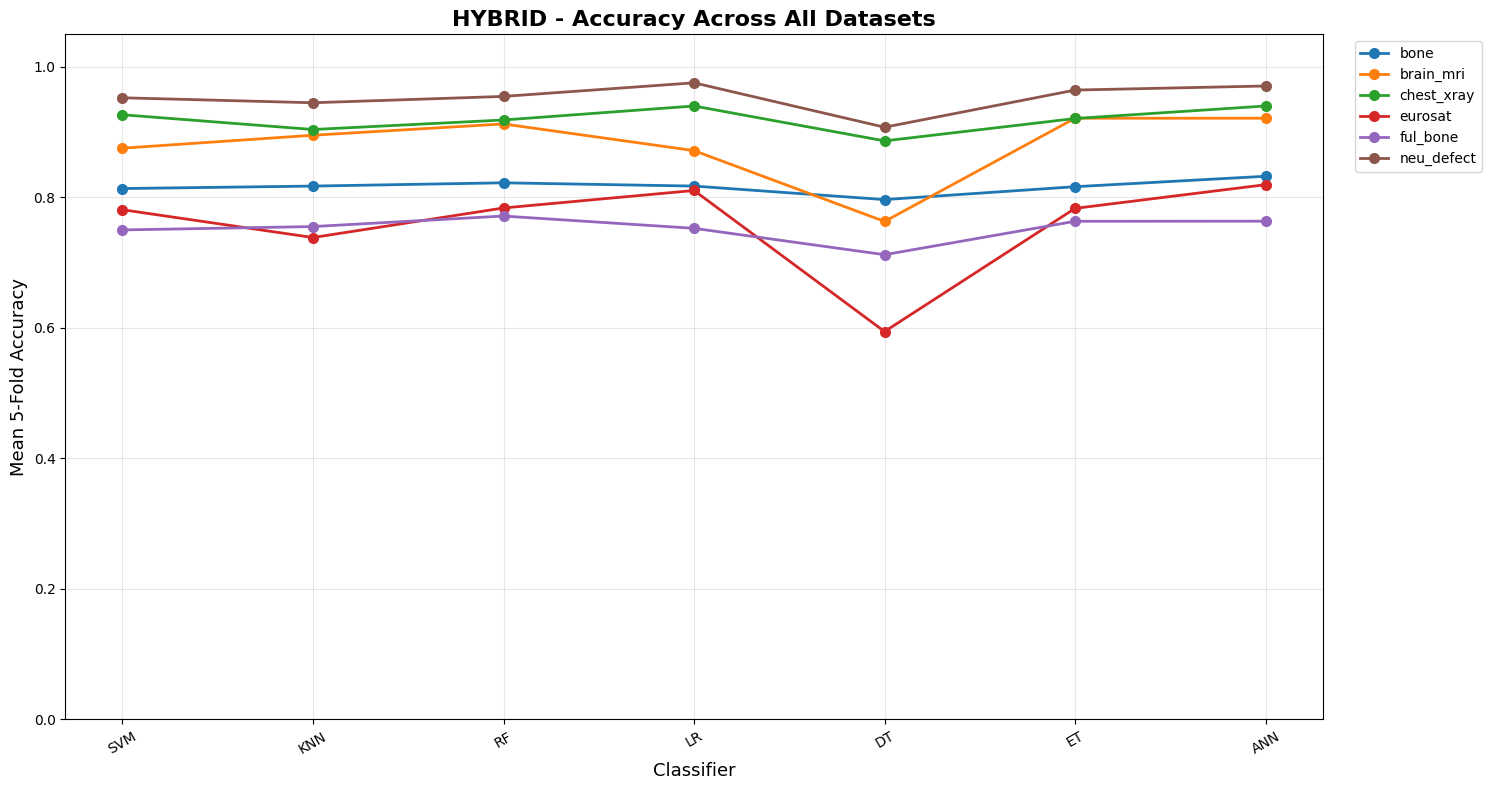

Saved plot: accuracy_plots\all_datasets_lbp.png


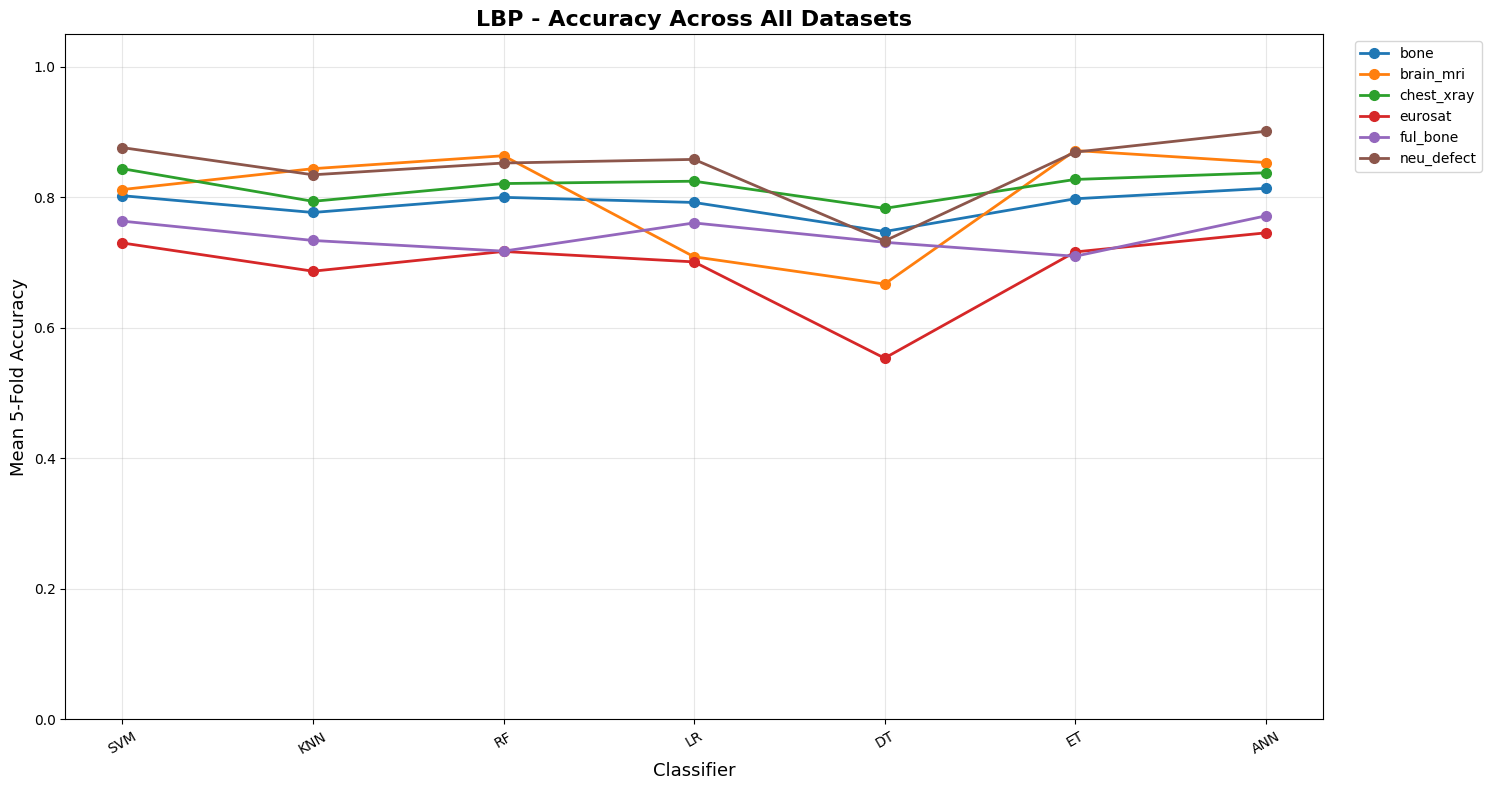

Saved plot: accuracy_plots\all_datasets_normal.png


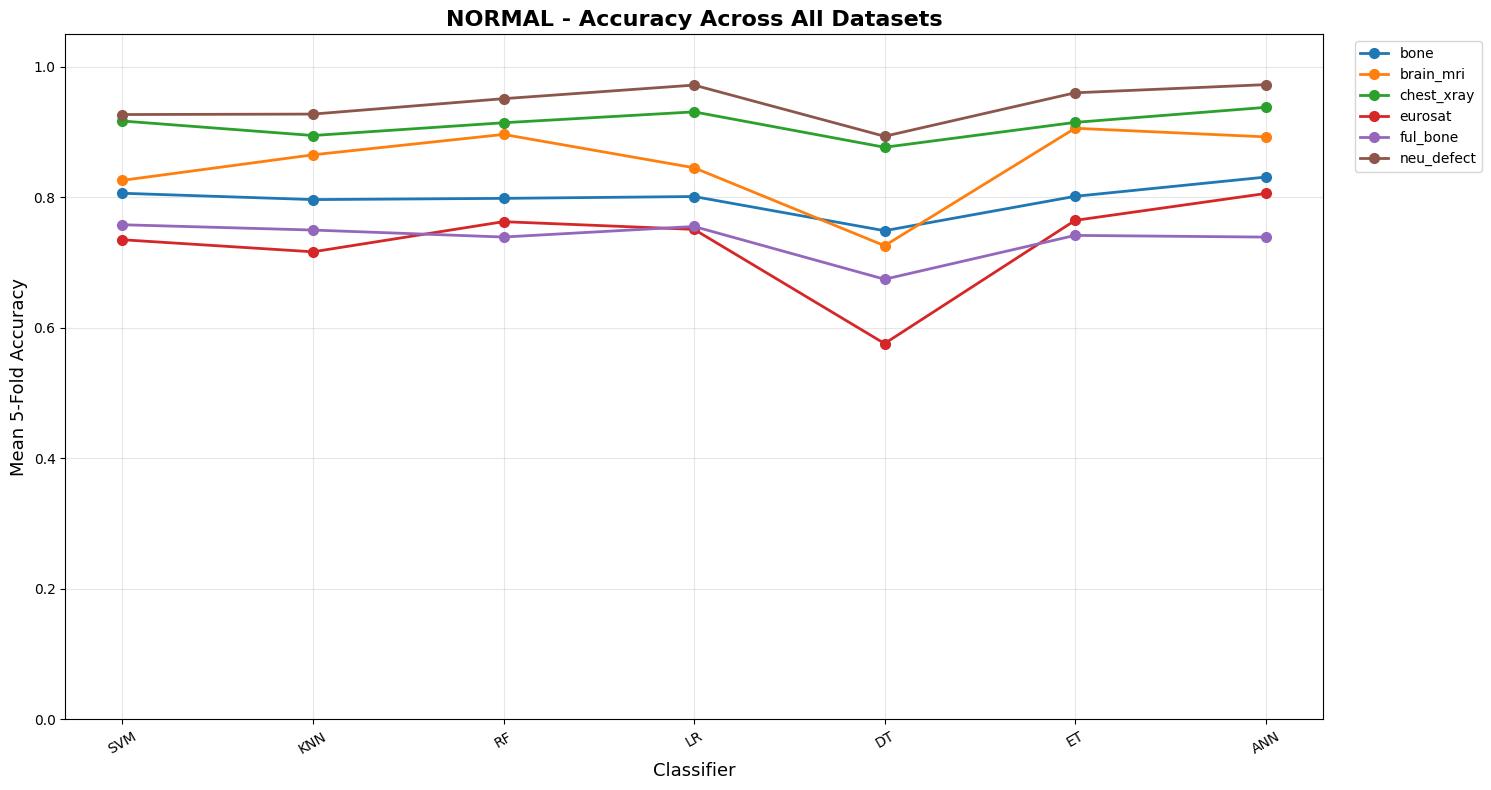



PLOTTING ALL DATASETS + ALL FEATURES

Saved combined plot:
accuracy_plots\ALL_DATASETS_ALL_FEATURES.png


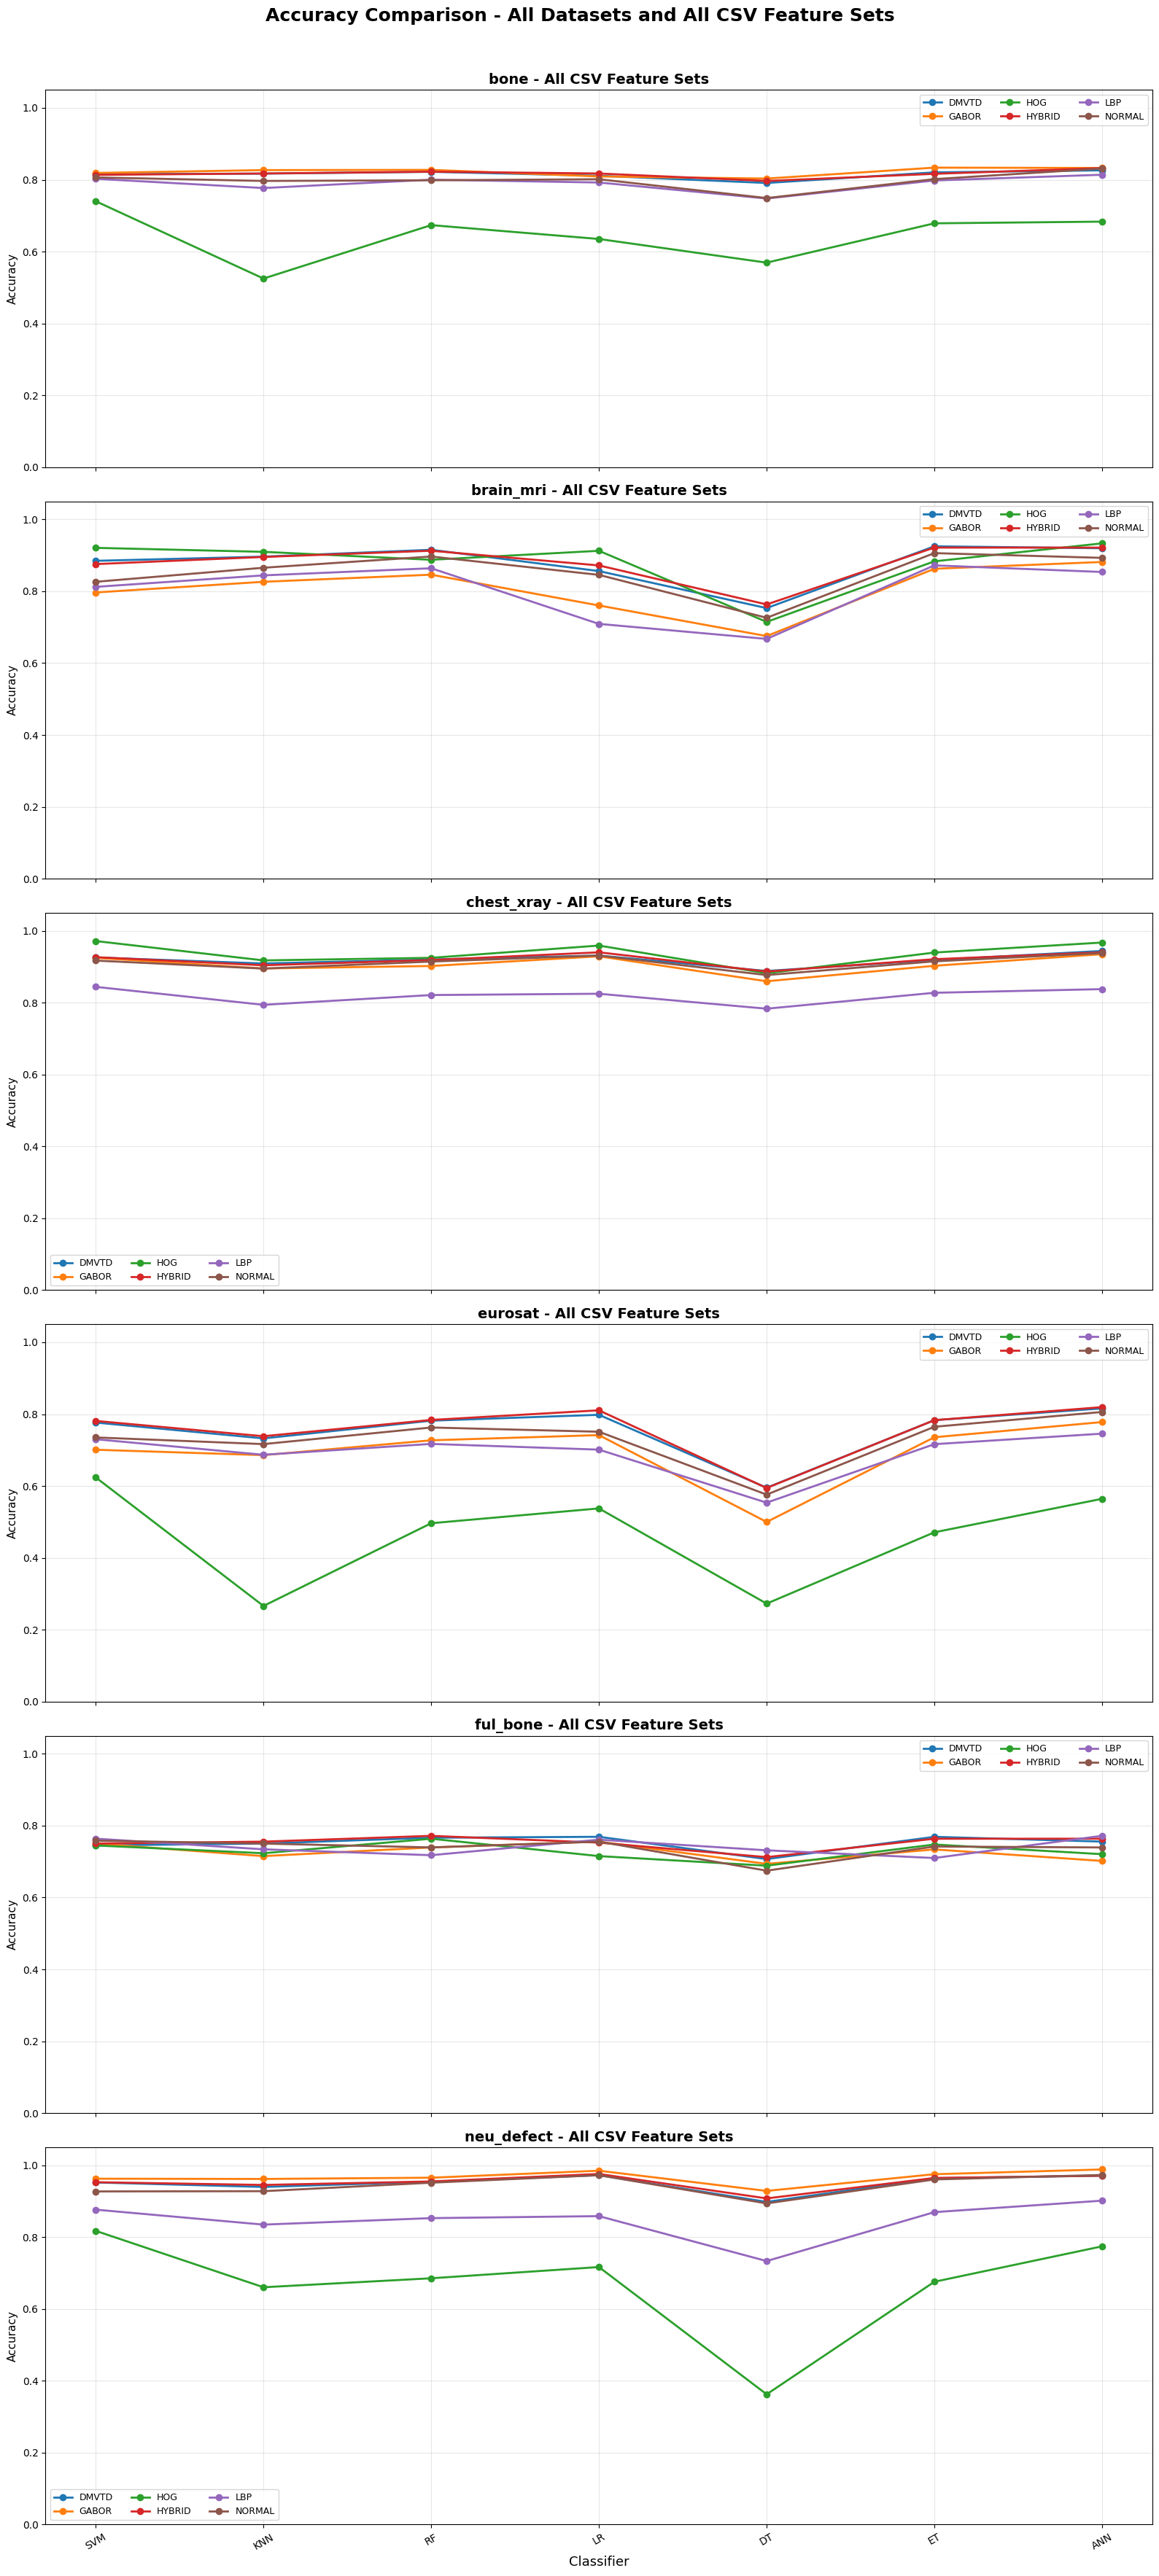


Wilcoxon test: bone | normal vs dmvtd
  SVM: p=0.062500
  KNN: p=0.125000
  RF: p=0.062500
  LR: p=0.062500
  DT: p=0.062500
  ET: p=0.062500
  ANN: p=0.625000

Wilcoxon test: bone | normal vs hybrid
  SVM: p=0.062500
  KNN: p=0.062500
  RF: p=0.062500
  LR: p=0.125000
  DT: p=0.062500
  ET: p=0.062500
  ANN: p=1.000000


Best NORMAL model: ANN
Best HYBRID model: ANN

McNemar's test — Normal-ANN vs Hybrid-ANN: statistic=157.0, p-value=0.866435

Wilcoxon test: brain_mri | normal vs dmvtd
  SVM: p=0.062500
  KNN: p=0.062500
  RF: p=0.062500
  LR: p=0.187500
  DT: p=0.062500
  ET: p=0.062500
  ANN: p=0.062500

Wilcoxon test: brain_mri | normal vs hybrid
  SVM: p=0.062500
  KNN: p=0.062500
  RF: p=0.062500
  LR: p=0.062500
  DT: p=0.062500
  ET: p=0.062500
  ANN: p=0.062500


Best NORMAL model: ET
Best HYBRID model: ANN

McNemar's test — Normal-ET vs Hybrid-ANN: statistic=180.0, p-value=0.000054

Wilcoxon test: chest_xray | normal vs dmvtd
  SVM: p=0.062500
  KNN: p=0.062500
  RF: p=0.312

In [11]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from scipy.stats import wilcoxon
from statsmodels.stats.contingency_tables import mcnemar

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader


# =====================================================
# SETTINGS
# =====================================================

GLCM_DIR = "glcm_5"

N_SPLITS = 5
RANDOM_STATE = 42

EPOCHS = 100
BATCH_SIZE = 32

# Save plots
SAVE_PLOTS = True

# Output directory
OUTPUT_DIR = "accuracy_plots"

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)


# =====================================================
# DEVICE
# =====================================================

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("\n" + "=" * 80)
print("DEVICE:", device)
print("=" * 80)


# =====================================================
# RANDOM SEED
# =====================================================

np.random.seed(
    RANDOM_STATE
)

torch.manual_seed(
    RANDOM_STATE
)

if torch.cuda.is_available():

    torch.cuda.manual_seed_all(
        RANDOM_STATE
    )


# =====================================================
# ANN MODEL
# =====================================================

class ANN(nn.Module):

    def __init__(
        self,
        input_size,
        num_classes
    ):

        super().__init__()

        self.network = nn.Sequential(

            nn.Linear(
                input_size,
                128
            ),

            nn.ReLU(),

            nn.Dropout(
                0.3
            ),

            nn.Linear(
                128,
                64
            ),

            nn.ReLU(),

            nn.Linear(
                64,
                32
            ),

            nn.ReLU(),

            nn.Linear(
                32,
                num_classes
            )
        )

    def forward(
        self,
        x
    ):

        return self.network(x)


# =====================================================
# TRAIN ANN
# =====================================================

def train_ann(
    X_train,
    X_test,
    y_train,
    verbose=False
):

    X_train_tensor = torch.tensor(
        X_train,
        dtype=torch.float32
    )

    X_test_tensor = torch.tensor(
        X_test,
        dtype=torch.float32
    )

    y_train_tensor = torch.tensor(
        y_train,
        dtype=torch.long
    )

    train_dataset = TensorDataset(
        X_train_tensor,
        y_train_tensor
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True
    )

    input_size = X_train.shape[1]

    num_classes = len(
        np.unique(y_train)
    )

    model = ANN(
        input_size,
        num_classes
    ).to(device)

    criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(
        model.parameters(),
        lr=0.001
    )

    # ---------------------------------------------
    # TRAINING
    # ---------------------------------------------

    for epoch in range(
        EPOCHS
    ):

        model.train()

        total_loss = 0.0

        for batch_X, batch_y in train_loader:

            batch_X = batch_X.to(
                device
            )

            batch_y = batch_y.to(
                device
            )

            outputs = model(
                batch_X
            )

            loss = criterion(
                outputs,
                batch_y
            )

            optimizer.zero_grad()

            loss.backward()

            optimizer.step()

            total_loss += loss.item()

        if (
            verbose
            and
            (epoch + 1) % 100 == 0
        ):

            print(
                f"    Epoch "
                f"[{epoch + 1}/{EPOCHS}] "
                f"Loss={total_loss:.4f}"
            )

    # ---------------------------------------------
    # PREDICTION
    # ---------------------------------------------

    model.eval()

    with torch.no_grad():

        X_test_tensor = (
            X_test_tensor.to(device)
        )

        outputs = model(
            X_test_tensor
        )

        _, predicted = torch.max(
            outputs,
            1
        )

        y_pred = (
            predicted
            .cpu()
            .numpy()
        )

    return y_pred


# =====================================================
# LOAD FEATURES AND LABELS
# =====================================================

def load_features_labels(
    file_path
):

    df = pd.read_csv(
        file_path
    )

    if "label" not in df.columns:

        raise ValueError(
            f"'label' column not found "
            f"in {file_path}"
        )

    # ---------------------------------------------
    # Encode labels
    # ---------------------------------------------

    label_encoder = LabelEncoder()

    y = label_encoder.fit_transform(
        df["label"]
    )

    # ---------------------------------------------
    # Features
    # ---------------------------------------------

    X = df.drop(
        columns=["label"]
    )

    X = X.apply(
        pd.to_numeric,
        errors="coerce"
    )

    X = X.replace(
        [np.inf, -np.inf],
        np.nan
    )

    return (
        X.to_numpy(),
        y
    )


# =====================================================
# RUN ONE CSV WITH 5-FOLD CV
# =====================================================

def run_experiment(
    file_path,
    dataset_name
):

    print("\n" + "=" * 80)
    print(
        f"RUNNING: {dataset_name}"
    )
    print(
        f"FILE: {file_path}"
    )
    print("=" * 80)

    # ---------------------------------------------
    # Load data
    # ---------------------------------------------

    X_raw, y = load_features_labels(
        file_path
    )

    # ---------------------------------------------
    # Check class counts
    # ---------------------------------------------

    class_counts = np.bincount(
        y
    )

    min_class_count = (
        class_counts.min()
    )

    if min_class_count < N_SPLITS:

        raise ValueError(
            f"{dataset_name}: "
            f"smallest class has only "
            f"{min_class_count} samples, "
            f"but N_SPLITS={N_SPLITS}"
        )

    # ---------------------------------------------
    # Stratified K-Fold
    # ---------------------------------------------

    skf = StratifiedKFold(
        n_splits=N_SPLITS,
        shuffle=True,
        random_state=RANDOM_STATE
    )

    # ---------------------------------------------
    # Models
    # ---------------------------------------------

    model_builders = {

        "SVM": lambda:
            SVC(
                kernel="rbf",
                C=1,
                gamma="scale"
            ),

        "KNN": lambda:
            KNeighborsClassifier(
                n_neighbors=5
            ),

        "RF": lambda:
            RandomForestClassifier(
                n_estimators=100,
                random_state=RANDOM_STATE,
                n_jobs=-1
            ),

        "LR": lambda:
            LogisticRegression(
                max_iter=500,
                random_state=RANDOM_STATE
            ),

        "DT": lambda:
            DecisionTreeClassifier(
                max_depth=5,
                random_state=RANDOM_STATE
            ),

        "ET": lambda:
            ExtraTreesClassifier(
                n_estimators=100,
                random_state=RANDOM_STATE,
                n_jobs=-1
            )
    }

    model_names = (
        list(model_builders.keys())
        + ["ANN"]
    )

    # ---------------------------------------------
    # Store fold metrics
    # ---------------------------------------------

    fold_accuracies = {
        name: []
        for name in model_names
    }

    fold_precisions = {
        name: []
        for name in model_names
    }

    fold_recalls = {
        name: []
        for name in model_names
    }

    fold_f1s = {
        name: []
        for name in model_names
    }

    # ---------------------------------------------
    # Out-of-fold predictions
    # ---------------------------------------------

    oof_preds = {

        name:
        np.zeros_like(y)

        for name in model_names
    }

    # =================================================
    # CROSS VALIDATION
    # =================================================

    fold_num = 0

    for train_idx, test_idx in skf.split(
        X_raw,
        y
    ):

        fold_num += 1

        print(
            f"\n----- Fold "
            f"{fold_num}/{N_SPLITS} -----"
        )

        X_train_raw = (
            X_raw[train_idx]
        )

        X_test_raw = (
            X_raw[test_idx]
        )

        y_train = (
            y[train_idx]
        )

        y_test = (
            y[test_idx]
        )

        # ---------------------------------------------
        # Imputation
        # ---------------------------------------------

        imputer = SimpleImputer(
            strategy="mean"
        )

        X_train = (
            imputer.fit_transform(
                X_train_raw
            )
        )

        X_test = (
            imputer.transform(
                X_test_raw
            )
        )

        # ---------------------------------------------
        # Scaling
        # ---------------------------------------------

        scaler = StandardScaler()

        X_train = (
            scaler.fit_transform(
                X_train
            )
        )

        X_test = (
            scaler.transform(
                X_test
            )
        )

        # =================================================
        # SKLEARN MODELS
        # =================================================

        for (
            name,
            build_model
        ) in model_builders.items():

            model = build_model()

            model.fit(
                X_train,
                y_train
            )

            y_pred = model.predict(
                X_test
            )

            # -----------------------------------------
            # Metrics
            # -----------------------------------------

            acc = accuracy_score(
                y_test,
                y_pred
            )

            precision = precision_score(
                y_test,
                y_pred,
                average="weighted",
                zero_division=0
            )

            recall = recall_score(
                y_test,
                y_pred,
                average="weighted",
                zero_division=0
            )

            f1 = f1_score(
                y_test,
                y_pred,
                average="weighted",
                zero_division=0
            )

            print(
                f"  {name}: "
                f"acc={acc:.4f} "
                f"prec={precision:.4f} "
                f"rec={recall:.4f} "
                f"f1={f1:.4f}"
            )

            fold_accuracies[
                name
            ].append(acc)

            fold_precisions[
                name
            ].append(precision)

            fold_recalls[
                name
            ].append(recall)

            fold_f1s[
                name
            ].append(f1)

            oof_preds[
                name
            ][test_idx] = y_pred

        # =================================================
        # ANN
        # =================================================

        y_pred_ann = train_ann(
            X_train,
            X_test,
            y_train
        )

        acc = accuracy_score(
            y_test,
            y_pred_ann
        )

        precision = precision_score(
            y_test,
            y_pred_ann,
            average="weighted",
            zero_division=0
        )

        recall = recall_score(
            y_test,
            y_pred_ann,
            average="weighted",
            zero_division=0
        )

        f1 = f1_score(
            y_test,
            y_pred_ann,
            average="weighted",
            zero_division=0
        )

        print(
            f"  ANN: "
            f"acc={acc:.4f} "
            f"prec={precision:.4f} "
            f"rec={recall:.4f} "
            f"f1={f1:.4f}"
        )

        fold_accuracies[
            "ANN"
        ].append(acc)

        fold_precisions[
            "ANN"
        ].append(precision)

        fold_recalls[
            "ANN"
        ].append(recall)

        fold_f1s[
            "ANN"
        ].append(f1)

        oof_preds[
            "ANN"
        ][test_idx] = y_pred_ann

    # =================================================
    # SUMMARY
    # =================================================

    print(
        f"\n--- {dataset_name}: "
        f"5-fold CV summary ---"
    )

    mean_accuracies = []

    std_accuracies = []

    for name in model_names:

        accs = np.array(
            fold_accuracies[name]
        )

        precs = np.array(
            fold_precisions[name]
        )

        recs = np.array(
            fold_recalls[name]
        )

        f1s = np.array(
            fold_f1s[name]
        )

        mean_acc = accs.mean()

        std_acc = accs.std()

        mean_accuracies.append(
            mean_acc
        )

        std_accuracies.append(
            std_acc
        )

        print(
            f"{name}: "
            f"acc={mean_acc:.4f}"
            f"±{std_acc:.4f}  "
            f"prec={precs.mean():.4f}"
            f"±{precs.std():.4f}  "
            f"rec={recs.mean():.4f}"
            f"±{recs.std():.4f}  "
            f"f1={f1s.mean():.4f}"
            f"±{f1s.std():.4f}"
        )

        # ---------------------------------------------
        # Classification report
        # ---------------------------------------------

        print(
            f"\nOut-of-fold "
            f"classification report — "
            f"{name}:"
        )

        print(
            classification_report(
                y,
                oof_preds[name],
                zero_division=0
            )
        )

    return {

        "model_names":
            model_names,

        "mean_accuracies":
            mean_accuracies,

        "std_accuracies":
            std_accuracies,

        "fold_accuracies":
            fold_accuracies,

        "oof_preds":
            oof_preds,

        "y_true":
            y
    }


# =====================================================
# AUTO-DETECT ALL CSV FILES
# =====================================================

def get_datasets():

    datasets = {}

    if not os.path.exists(
        GLCM_DIR
    ):

        raise FileNotFoundError(
            f"Directory not found: "
            f"{GLCM_DIR}"
        )

    # ---------------------------------------------
    # Each subfolder is a dataset
    # ---------------------------------------------

    for dataset_name in sorted(
        os.listdir(GLCM_DIR)
    ):

        dataset_path = os.path.join(
            GLCM_DIR,
            dataset_name
        )

        if not os.path.isdir(
            dataset_path
        ):
            continue

        # -----------------------------------------
        # Find EVERY CSV automatically
        # -----------------------------------------

        csv_files = {}

        for filename in sorted(
            os.listdir(dataset_path)
        ):

            if filename.lower().endswith(
                ".csv"
            ):

                feature_name = os.path.splitext(
                    filename
                )[0]

                csv_files[
                    feature_name
                ] = os.path.join(
                    dataset_path,
                    filename
                )

        if len(csv_files) == 0:
            continue

        datasets[
            dataset_name
        ] = csv_files

    return datasets


# =====================================================
# PRINT DETECTED DATASETS
# =====================================================

def print_detected_datasets(
    datasets
):

    print("\n")
    print("=" * 80)
    print("DETECTED DATASETS AND CSV FILES")
    print("=" * 80)

    total_csv = 0

    for dataset_name, files in datasets.items():

        print(
            f"\n{dataset_name}:"
        )

        for feature_name, file_path in files.items():

            print(
                f"    {feature_name:15s} "
                f"-> {file_path}"
            )

            total_csv += 1

    print("\n" + "-" * 80)

    print(
        f"Total dataset folders: "
        f"{len(datasets)}"
    )

    print(
        f"Total CSV files: "
        f"{total_csv}"
    )

    print("=" * 80)


# =====================================================
# WILCOXON TEST
# =====================================================

def run_wilcoxon_pair(
    dataset_name,
    feature_a,
    feature_b,
    results_a,
    results_b
):

    print(
        f"\nWilcoxon test: "
        f"{dataset_name} | "
        f"{feature_a} vs {feature_b}"
    )

    model_names = (
        results_a["model_names"]
    )

    for name in model_names:

        vals_a = np.array(
            results_a[
                "fold_accuracies"
            ][name]
        )

        vals_b = np.array(
            results_b[
                "fold_accuracies"
            ][name]
        )

        try:

            if np.allclose(
                vals_a,
                vals_b
            ):

                p_value = float(
                    "nan"
                )

            else:

                _, p_value = wilcoxon(
                    vals_a,
                    vals_b
                )

        except ValueError:

            p_value = float(
                "nan"
            )

        print(
            f"  {name}: "
            f"p={p_value:.6f}"
        )


# =====================================================
# MCNEMAR TEST
# =====================================================

def run_mcnemar_test(
    y_true,
    pred_a,
    pred_b,
    label_a,
    label_b
):

    a = 0
    b = 0
    c = 0
    d = 0

    for (
        yt,
        pa,
        pb
    ) in zip(
        y_true,
        pred_a,
        pred_b
    ):

        a_correct = (
            pa == yt
        )

        b_correct = (
            pb == yt
        )

        if (
            a_correct
            and
            b_correct
        ):

            a += 1

        elif (
            a_correct
            and
            not b_correct
        ):

            b += 1

        elif (
            not a_correct
            and
            b_correct
        ):

            c += 1

        else:

            d += 1

    table = [
        [a, b],
        [c, d]
    ]

    try:

        result = mcnemar(
            table,
            exact=True
        )

        print(
            f"\nMcNemar's test — "
            f"{label_a} vs {label_b}: "
            f"statistic={result.statistic}, "
            f"p-value={result.pvalue:.6f}"
        )

        return result.pvalue

    except Exception as e:

        print(
            "McNemar test failed:",
            e
        )

        return np.nan


# =====================================================
# PLOT 1
# ALL FEATURES FOR EACH DATASET
# =====================================================

def plot_all_features_per_dataset(
    all_results,
    dataset_name
):

    results = all_results[
        dataset_name
    ]

    feature_names = list(
        results.keys()
    )

    if len(feature_names) == 0:
        return

    # Get model names from first result
    model_names = results[
        feature_names[0]
    ]["model_names"]

    # ---------------------------------------------
    # Figure
    # ---------------------------------------------

    plt.figure(
        figsize=(15, 8)
    )

    # ---------------------------------------------
    # Plot every CSV
    # ---------------------------------------------

    for feature_name in feature_names:

        accuracies = results[
            feature_name
        ]["mean_accuracies"]

        plt.plot(
            model_names,
            accuracies,
            marker="o",
            linewidth=2,
            markersize=7,
            label=feature_name.upper()
        )

    # ---------------------------------------------
    # Formatting
    # ---------------------------------------------

    plt.title(
        f"{dataset_name} - "
        f"All Feature Sets Accuracy",
        fontsize=16,
        fontweight="bold"
    )

    plt.xlabel(
        "Classifier",
        fontsize=13
    )

    plt.ylabel(
        "Mean 5-Fold Accuracy",
        fontsize=13
    )

    plt.ylim(
        0,
        1.05
    )

    plt.grid(
        True,
        alpha=0.3
    )

    plt.legend(
        bbox_to_anchor=(
            1.02,
            1
        ),
        loc="upper left"
    )

    plt.xticks(
        rotation=30
    )

    plt.tight_layout()

    if SAVE_PLOTS:

        filename = os.path.join(
            OUTPUT_DIR,
            f"{dataset_name}_all_features.png"
        )

        plt.savefig(
            filename,
            dpi=300,
            bbox_inches="tight"
        )

        print(
            f"\nSaved plot: {filename}"
        )

    plt.show()


# =====================================================
# PLOT 2
# ALL DATASETS FOR EACH FEATURE
# =====================================================

def plot_all_datasets_per_feature(
    all_results
):

    # ---------------------------------------------
    # Find all feature names
    # ---------------------------------------------

    feature_names = sorted(
        set(
            feature
            for dataset_results
            in all_results.values()
            for feature
            in dataset_results.keys()
        )
    )

    print(
        "\nFeatures found:"
    )

    for feature in feature_names:

        print(
            f"  - {feature}"
        )

    # ---------------------------------------------
    # Create one plot per feature
    # ---------------------------------------------

    for feature_name in feature_names:

        plt.figure(
            figsize=(15, 8)
        )

        plotted = False

        for dataset_name in sorted(
            all_results.keys()
        ):

            if feature_name not in all_results[
                dataset_name
            ]:

                continue

            results = all_results[
                dataset_name
            ][feature_name]

            model_names = results[
                "model_names"
            ]

            accuracies = results[
                "mean_accuracies"
            ]

            plt.plot(
                model_names,
                accuracies,
                marker="o",
                linewidth=2,
                markersize=7,
                label=dataset_name
            )

            plotted = True

        if not plotted:

            plt.close()

            continue

        plt.title(
            f"{feature_name.upper()} - "
            f"Accuracy Across All Datasets",
            fontsize=16,
            fontweight="bold"
        )

        plt.xlabel(
            "Classifier",
            fontsize=13
        )

        plt.ylabel(
            "Mean 5-Fold Accuracy",
            fontsize=13
        )

        plt.ylim(
            0,
            1.05
        )

        plt.grid(
            True,
            alpha=0.3
        )

        plt.legend(
            bbox_to_anchor=(
                1.02,
                1
            ),
            loc="upper left"
        )

        plt.xticks(
            rotation=30
        )

        plt.tight_layout()

        if SAVE_PLOTS:

            filename = os.path.join(
                OUTPUT_DIR,
                f"all_datasets_{feature_name}.png"
            )

            plt.savefig(
                filename,
                dpi=300,
                bbox_inches="tight"
            )

            print(
                f"Saved plot: {filename}"
            )

        plt.show()


# =====================================================
# PLOT 3
# ONE BIG PLOT:
# ALL DATASETS + ALL CSV FEATURES
# =====================================================

def plot_everything(
    all_results
):

    # ---------------------------------------------
    # Collect every dataset
    # ---------------------------------------------

    dataset_names = sorted(
        all_results.keys()
    )

    # ---------------------------------------------
    # Create subplot for each dataset
    # ---------------------------------------------

    n_datasets = len(
        dataset_names
    )

    if n_datasets == 0:

        return

    fig, axes = plt.subplots(
        nrows=n_datasets,
        ncols=1,
        figsize=(
            16,
            6 * n_datasets
        ),
        sharex=True
    )

    if n_datasets == 1:

        axes = [axes]

    # ---------------------------------------------
    # Plot each dataset
    # ---------------------------------------------

    for ax, dataset_name in zip(
        axes,
        dataset_names
    ):

        dataset_results = (
            all_results[
                dataset_name
            ]
        )

        # Get model names
        first_feature = next(
            iter(
                dataset_results
            )
        )

        model_names = (
            dataset_results[
                first_feature
            ]["model_names"]
        )

        # -----------------------------------------
        # Every CSV / feature
        # -----------------------------------------

        for feature_name in sorted(
            dataset_results.keys()
        ):

            accuracies = (
                dataset_results[
                    feature_name
                ]["mean_accuracies"]
            )

            ax.plot(
                model_names,
                accuracies,
                marker="o",
                linewidth=2,
                markersize=6,
                label=feature_name.upper()
            )

        # -----------------------------------------
        # Dataset title
        # -----------------------------------------

        ax.set_title(
            f"{dataset_name} - "
            f"All CSV Feature Sets",
            fontsize=14,
            fontweight="bold"
        )

        ax.set_ylabel(
            "Accuracy",
            fontsize=11
        )

        ax.set_ylim(
            0,
            1.05
        )

        ax.grid(
            True,
            alpha=0.3
        )

        ax.legend(
            fontsize=9,
            ncol=3
        )

    # ---------------------------------------------
    # X-axis
    # ---------------------------------------------

    axes[-1].set_xlabel(
        "Classifier",
        fontsize=13
    )

    plt.xticks(
        rotation=30
    )

    fig.suptitle(
        "Accuracy Comparison - "
        "All Datasets and All CSV Feature Sets",
        fontsize=18,
        fontweight="bold"
    )

    plt.tight_layout(
        rect=[
            0,
            0,
            1,
            0.97
        ]
    )

    if SAVE_PLOTS:

        filename = os.path.join(
            OUTPUT_DIR,
            "ALL_DATASETS_ALL_FEATURES.png"
        )

        plt.savefig(
            filename,
            dpi=300,
            bbox_inches="tight"
        )

        print(
            f"\nSaved combined plot:"
            f"\n{filename}"
        )

    plt.show()


# =====================================================
# CREATE SUMMARY CSV
# =====================================================

def create_accuracy_summary(
    all_results
):

    rows = []

    for dataset_name in sorted(
        all_results.keys()
    ):

        for feature_name in sorted(
            all_results[
                dataset_name
            ].keys()
        ):

            results = all_results[
                dataset_name
            ][feature_name]

            model_names = results[
                "model_names"
            ]

            accuracies = results[
                "mean_accuracies"
            ]

            stds = results[
                "std_accuracies"
            ]

            for (
                model,
                accuracy,
                std
            ) in zip(
                model_names,
                accuracies,
                stds
            ):

                rows.append({

                    "Dataset":
                        dataset_name,

                    "Feature":
                        feature_name,

                    "Model":
                        model,

                    "Accuracy":
                        accuracy,

                    "Std":
                        std
                })

    df = pd.DataFrame(
        rows
    )

    filename = os.path.join(
        OUTPUT_DIR,
        "accuracy_summary.csv"
    )

    df.to_csv(
        filename,
        index=False
    )

    print(
        f"\nSaved accuracy summary:"
        f"\n{filename}"
    )

    return df


# =====================================================
# RUN ALL
# =====================================================

def run_all():

    # =================================================
    # FIND ALL DATASETS
    # =================================================

    datasets = get_datasets()

    if len(datasets) == 0:

        print(
            "\nNo datasets found!"
        )

        return

    # =================================================
    # PRINT ALL FILES
    # =================================================

    print_detected_datasets(
        datasets
    )

    # =================================================
    # STORE ALL RESULTS
    # =================================================

    all_results = {}

    # =================================================
    # RUN EVERY CSV
    # =================================================

    for dataset_name in sorted(
        datasets.keys()
    ):

        all_results[
            dataset_name
        ] = {}

        print("\n")
        print(
            "#" * 80
        )

        print(
            f"DATASET: "
            f"{dataset_name.upper()}"
        )

        print(
            "#" * 80
        )

        files = datasets[
            dataset_name
        ]

        # ---------------------------------------------
        # Run EVERY CSV in this dataset
        # ---------------------------------------------

        for feature_name in sorted(
            files.keys()
        ):

            file_path = files[
                feature_name
            ]

            experiment_name = (
                f"{dataset_name}_"
                f"{feature_name.upper()}"
            )

            try:

                results = run_experiment(
                    file_path,
                    experiment_name
                )

                all_results[
                    dataset_name
                ][feature_name] = results

            except Exception as e:

                print(
                    "\nERROR while running:"
                )

                print(
                    f"Dataset: "
                    f"{dataset_name}"
                )

                print(
                    f"Feature: "
                    f"{feature_name}"
                )

                print(
                    f"File: "
                    f"{file_path}"
                )

                print(
                    f"Error: {e}"
                )

                print(
                    "Skipping this CSV..."
                )

    # =================================================
    # RESULTS CHECK
    # =================================================

    print("\n")
    print(
        "=" * 80
    )

    print(
        "ALL EXPERIMENTS FINISHED"
    )

    print(
        "=" * 80
    )

    # =================================================
    # CREATE SUMMARY CSV
    # =================================================

    summary_df = create_accuracy_summary(
        all_results
    )

    # =================================================
    # DISPLAY SUMMARY
    # =================================================

    print("\n")
    print(
        "=" * 80
    )

    print(
        "ACCURACY SUMMARY"
    )

    print(
        "=" * 80
    )

    print(
        summary_df.to_string(
            index=False
        )
    )

    # =================================================
    # PLOT 1:
    # ALL FEATURES FOR EACH DATASET
    # =================================================

    print("\n")
    print(
        "=" * 80
    )

    print(
        "PLOTTING ALL FEATURES FOR EACH DATASET"
    )

    print(
        "=" * 80
    )

    for dataset_name in sorted(
        all_results.keys()
    ):

        if len(
            all_results[
                dataset_name
            ]
        ) == 0:

            continue

        plot_all_features_per_dataset(
            all_results,
            dataset_name
        )

    # =================================================
    # PLOT 2:
    # ALL DATASETS FOR EACH FEATURE
    # =================================================

    print("\n")
    print(
        "=" * 80
    )

    print(
        "PLOTTING EACH FEATURE ACROSS ALL DATASETS"
    )

    print(
        "=" * 80
    )

    plot_all_datasets_per_feature(
        all_results
    )

    # =================================================
    # PLOT 3:
    # EVERYTHING IN ONE FIGURE
    # =================================================

    print("\n")
    print(
        "=" * 80
    )

    print(
        "PLOTTING ALL DATASETS + ALL FEATURES"
    )

    print(
        "=" * 80
    )

    plot_everything(
        all_results
    )

    # =================================================
    # OPTIONAL STATISTICAL TESTS
    # =================================================

    # -------------------------------------------------
    # If Raw, DMVTD and Hybrid exist, perform the
    # original Wilcoxon comparisons.
    # -------------------------------------------------

    for dataset_name in sorted(
        all_results.keys()
    ):

        dataset_results = (
            all_results[
                dataset_name
            ]
        )

        if (
            "normal" in dataset_results
            and
            "dmvtd" in dataset_results
        ):

            run_wilcoxon_pair(
                dataset_name,
                "normal",
                "dmvtd",
                dataset_results[
                    "normal"
                ],
                dataset_results[
                    "dmvtd"
                ]
            )

        if (
            "normal" in dataset_results
            and
            "hybrid" in dataset_results
        ):

            run_wilcoxon_pair(
                dataset_name,
                "normal",
                "hybrid",
                dataset_results[
                    "normal"
                ],
                dataset_results[
                    "hybrid"
                ]
            )

        # -------------------------------------------------
        # Original McNemar:
        # Best normal vs best hybrid
        # -------------------------------------------------

        if (
            "normal" in dataset_results
            and
            "hybrid" in dataset_results
        ):

            normal_results = (
                dataset_results[
                    "normal"
                ]
            )

            hybrid_results = (
                dataset_results[
                    "hybrid"
                ]
            )

            model_names = (
                normal_results[
                    "model_names"
                ]
            )

            best_normal_idx = int(
                np.argmax(
                    normal_results[
                        "mean_accuracies"
                    ]
                )
            )

            best_hybrid_idx = int(
                np.argmax(
                    hybrid_results[
                        "mean_accuracies"
                    ]
                )
            )

            best_normal_model = (
                model_names[
                    best_normal_idx
                ]
            )

            best_hybrid_model = (
                model_names[
                    best_hybrid_idx
                ]
            )

            print("\n")
            print(
                f"Best NORMAL model: "
                f"{best_normal_model}"
            )

            print(
                f"Best HYBRID model: "
                f"{best_hybrid_model}"
            )

            run_mcnemar_test(

                normal_results[
                    "y_true"
                ],

                normal_results[
                    "oof_preds"
                ][
                    best_normal_model
                ],

                hybrid_results[
                    "oof_preds"
                ][
                    best_hybrid_model
                ],

                f"Normal-{best_normal_model}",

                f"Hybrid-{best_hybrid_model}"
            )


# =====================================================
# MAIN
# =====================================================

if __name__ == "__main__":

    run_all()

In [8]:
import os
import time
import random

import cv2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from scipy.stats import wilcoxon
from statsmodels.stats.contingency_tables import mcnemar

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import (
    TensorDataset,
    DataLoader
)


# ============================================================
# SETTINGS
# ============================================================

GLCM_DIR = "glcm_5"

IMG_SIZE = 128

MAX_SAMPLES = 2000

N_SPLITS = 5

RANDOM_STATE = 42

EPOCHS = 100
EPOCHS2=5
BATCH_SIZE = 32

LEARNING_RATE = 0.001

NUM_WORKERS = 0


# ============================================================
# DATASET IMAGE PATHS
#
# USE THE SAME PATHS AS YOUR FEATURE EXTRACTION CODE
# ============================================================

DATASET_IMAGE_PATHS = {

    "ful_bone":
        "Dataset",

    "bone":
        "clahe_output",

    # --------------------------------------------------------
    # CHANGE THESE IF YOUR ORIGINAL PATHS ARE DIFFERENT
    # --------------------------------------------------------

    "neu_defect":
        NEU_IMAGES,

    "brain_mri":
        BRAIN_IMAGES,

    "chest_xray":
        CHEST_IMAGES,

    "eurosat":
        EUROSAT_IMAGES
}


# ============================================================
# DEVICE
# ============================================================

device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print(
    "\n=================================================="
)

print(
    f"Using device: {device}"
)

if torch.cuda.is_available():

    print(
        f"GPU: {torch.cuda.get_device_name(0)}"
    )

print(
    "=================================================="
)


# ============================================================
# RANDOM SEEDS
# ============================================================

np.random.seed(
    RANDOM_STATE
)

random.seed(
    RANDOM_STATE
)

torch.manual_seed(
    RANDOM_STATE
)

if torch.cuda.is_available():

    torch.cuda.manual_seed_all(
        RANDOM_STATE
    )


# ============================================================
# CNN MODEL
# ============================================================

class CNN(nn.Module):

    def __init__(
        self,
        num_classes
    ):

        super().__init__()

        # ====================================================
        # FEATURE EXTRACTION
        # ====================================================

        self.features = nn.Sequential(

            # ------------------------------------------------
            # BLOCK 1
            # ------------------------------------------------

            nn.Conv2d(
                in_channels=1,
                out_channels=32,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(
                32
            ),

            nn.ReLU(
                inplace=True
            ),

            nn.MaxPool2d(
                kernel_size=2
            ),

            # ------------------------------------------------
            # BLOCK 2
            # ------------------------------------------------

            nn.Conv2d(
                in_channels=32,
                out_channels=64,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(
                64
            ),

            nn.ReLU(
                inplace=True
            ),

            nn.MaxPool2d(
                kernel_size=2
            ),

            # ------------------------------------------------
            # BLOCK 3
            # ------------------------------------------------

            nn.Conv2d(
                in_channels=64,
                out_channels=128,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(
                128
            ),

            nn.ReLU(
                inplace=True
            ),

            nn.MaxPool2d(
                kernel_size=2
            ),

            # ------------------------------------------------
            # BLOCK 4
            # ------------------------------------------------

            nn.Conv2d(
                in_channels=128,
                out_channels=256,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(
                256
            ),

            nn.ReLU(
                inplace=True
            ),

            # ------------------------------------------------
            # Adaptive pooling
            # ------------------------------------------------

            nn.AdaptiveAvgPool2d(
                (1, 1)
            )
        )

        # ====================================================
        # CLASSIFIER
        # ====================================================

        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Linear(
                256,
                128
            ),

            nn.ReLU(
                inplace=True
            ),

            nn.Dropout(
                0.4
            ),

            nn.Linear(
                128,
                num_classes
            )
        )


    def forward(
        self,
        x
    ):

        x = self.features(
            x
        )

        x = self.classifier(
            x
        )

        return x


# ============================================================
# CNN IMAGE PREPROCESSING
# ============================================================

def preprocess_cnn_image(
    img
):

    # --------------------------------------------------------
    # Resize
    # --------------------------------------------------------

    img = cv2.resize(
        img,
        (
            IMG_SIZE,
            IMG_SIZE
        )
    )

    # --------------------------------------------------------
    # Grayscale
    # --------------------------------------------------------

    if len(
        img.shape
    ) == 3:

        img = cv2.cvtColor(
            img,
            cv2.COLOR_BGR2GRAY
        )

    # --------------------------------------------------------
    # UINT8
    # --------------------------------------------------------

    img = np.asarray(
        img,
        dtype=np.uint8
    )

    # --------------------------------------------------------
    # CLAHE
    #
    # SAME preprocessing used in your feature extraction
    # --------------------------------------------------------

    clahe = cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(
            8,
            8
        )
    )

    img = clahe.apply(
        img
    )

    # --------------------------------------------------------
    # Normalize 0-1
    # --------------------------------------------------------

    img = img.astype(
        np.float32
    )

    img /= 255.0

    # --------------------------------------------------------
    # Add channel dimension
    #
    # H x W
    #
    # becomes:
    #
    # 1 x H x W
    # --------------------------------------------------------

    img = np.expand_dims(
        img,
        axis=0
    )

    return img


# ============================================================
# FIND CLASS DIRECTORIES
# ============================================================

def get_class_directories(
    dataset_path
):

    if not os.path.exists(
        dataset_path
    ):

        raise FileNotFoundError(
            f"Dataset not found: {dataset_path}"
        )

    class_dirs = [

        d

        for d in sorted(
            os.listdir(
                dataset_path
            )
        )

        if os.path.isdir(
            os.path.join(
                dataset_path,
                d
            )
        )
    ]

    if len(
        class_dirs
    ) == 0:

        raise ValueError(
            f"No class folders found in "
            f"{dataset_path}"
        )

    return class_dirs


# ============================================================
# LOAD CNN DATASET
#
# SAME BALANCED SAMPLING LOGIC AS FEATURE EXTRACTION
# ============================================================

def load_cnn_dataset(
    dataset_path
):

    print(
        "\nLoading CNN dataset:"
    )

    print(
        dataset_path
    )

    class_dirs = get_class_directories(
        dataset_path
    )

    n_classes = len(
        class_dirs
    )

    # --------------------------------------------------------
    # Balanced sample count
    # --------------------------------------------------------

    samples_per_class = (
        MAX_SAMPLES //
        n_classes
    )

    print(
        f"Number of classes: {n_classes}"
    )

    print(
        f"Maximum samples: {MAX_SAMPLES}"
    )

    print(
        f"Samples per class: "
        f"{samples_per_class}"
    )

    # --------------------------------------------------------
    # Store image paths
    # --------------------------------------------------------

    image_data = []

    # --------------------------------------------------------
    # Read each class
    # --------------------------------------------------------

    for class_name in class_dirs:

        class_path = os.path.join(
            dataset_path,
            class_name
        )

        class_files = []

        # ----------------------------------------------------
        # Find images
        # ----------------------------------------------------

        for img_name in os.listdir(
            class_path
        ):

            if not img_name.lower().endswith(
                (
                    ".jpg",
                    ".jpeg",
                    ".png",
                    ".bmp",
                    ".tif",
                    ".tiff"
                )
            ):

                continue

            img_path = os.path.join(
                class_path,
                img_name
            )

            class_files.append(
                img_path
            )

        # ----------------------------------------------------
        # Deterministic shuffle
        # ----------------------------------------------------

        rng = np.random.default_rng(
            RANDOM_STATE
        )

        rng.shuffle(
            class_files
        )

        # ----------------------------------------------------
        # Balanced selection
        # ----------------------------------------------------

        selected = class_files[
            :samples_per_class
        ]

        print(
            f"{class_name}: "
            f"{len(selected)} images"
        )

        # ----------------------------------------------------
        # Store
        # ----------------------------------------------------

        for img_path in selected:

            image_data.append(
                (
                    img_path,
                    class_name
                )
            )

    # --------------------------------------------------------
    # Final deterministic shuffle
    # --------------------------------------------------------

    rng = np.random.default_rng(
        RANDOM_STATE
    )

    rng.shuffle(
        image_data
    )

    # --------------------------------------------------------
    # Load images
    # --------------------------------------------------------

    images = []

    labels = []

    for img_path, label in image_data:

        img = cv2.imread(
            img_path,
            cv2.IMREAD_GRAYSCALE
        )

        if img is None:

            print(
                f"WARNING: Could not read "
                f"{img_path}"
            )

            continue

        img = preprocess_cnn_image(
            img
        )

        images.append(
            img
        )

        labels.append(
            label
        )

    # --------------------------------------------------------
    # Convert
    # --------------------------------------------------------

    images = np.asarray(
        images,
        dtype=np.float32
    )

    # --------------------------------------------------------
    # Encode labels
    # --------------------------------------------------------

    label_encoder = LabelEncoder()

    labels = label_encoder.fit_transform(
        labels
    )

    print(
        f"\nSuccessfully loaded: "
        f"{len(images)} images"
    )

    print(
        f"Image shape: "
        f"{images.shape}"
    )

    print(
        f"Number of classes: "
        f"{len(label_encoder.classes_)}"
    )

    print(
        f"Classes: "
        f"{list(label_encoder.classes_)}"
    )

    return (
        images,
        labels,
        label_encoder
    )


# ============================================================
# TRAIN CNN - ONE FOLD
# ============================================================

def train_cnn(
    X_train,
    X_test,
    y_train,
    y_test,
    num_classes,
    verbose=True
):

    # --------------------------------------------------------
    # Tensor conversion
    # --------------------------------------------------------

    X_train_tensor = torch.tensor(
        X_train,
        dtype=torch.float32
    )

    X_test_tensor = torch.tensor(
        X_test,
        dtype=torch.float32
    )

    y_train_tensor = torch.tensor(
        y_train,
        dtype=torch.long
    )

    y_test_tensor = torch.tensor(
        y_test,
        dtype=torch.long
    )

    # --------------------------------------------------------
    # Dataset
    # --------------------------------------------------------

    train_dataset = TensorDataset(
        X_train_tensor,
        y_train_tensor
    )

    test_dataset = TensorDataset(
        X_test_tensor,
        y_test_tensor
    )

    # --------------------------------------------------------
    # DataLoader
    # --------------------------------------------------------

    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS
    )

    # --------------------------------------------------------
    # Model
    # --------------------------------------------------------

    model = CNN(
        num_classes=num_classes
    ).to(
        device
    )

    # --------------------------------------------------------
    # Loss
    # --------------------------------------------------------

    criterion = nn.CrossEntropyLoss()

    # --------------------------------------------------------
    # Optimizer
    # --------------------------------------------------------

    optimizer = optim.Adam(
        model.parameters(),
        lr=LEARNING_RATE
    )

    # --------------------------------------------------------
    # Training timer
    # --------------------------------------------------------

    start_time = time.time()

    # --------------------------------------------------------
    # Training
    # --------------------------------------------------------

    for epoch in range(EPOCHS2):

        model.train()

        total_loss = 0.0

        correct = 0

        total = 0

        for batch_X, batch_y in train_loader:

            batch_X = batch_X.to(
                device
            )

            batch_y = batch_y.to(
                device
            )

            # ----------------------------------------------
            # Forward
            # ----------------------------------------------

            outputs = model(
                batch_X
            )

            loss = criterion(
                outputs,
                batch_y
            )

            # ----------------------------------------------
            # Backward
            # ----------------------------------------------

            optimizer.zero_grad()

            loss.backward()

            optimizer.step()

            # ----------------------------------------------
            # Statistics
            # ----------------------------------------------

            total_loss += loss.item()

            _, predicted = torch.max(
                outputs,
                1
            )

            total += batch_y.size(
                0
            )

            correct += (
                predicted == batch_y
            ).sum().item()

        # ----------------------------------------------------
        # Epoch progress
        # ----------------------------------------------------

        train_accuracy = (
            correct / total
        )

        if verbose:

            if (
                (epoch + 1) % 10 == 0
                or
                epoch == 0
            ):

                print(
                    f"    Epoch "
                    f"{epoch + 1:03d}/{EPOCHS2} | "
                    f"Loss={total_loss:.4f} | "
                    f"Train Acc="
                    f"{train_accuracy:.4f}"
                )

    # --------------------------------------------------------
    # Training time
    # --------------------------------------------------------

    training_time = (
        time.time() -
        start_time
    )

    # --------------------------------------------------------
    # Evaluation
    # --------------------------------------------------------

    model.eval()

    predictions = []

    true_labels = []

    inference_start = time.time()

    with torch.no_grad():

        for batch_X, batch_y in test_loader:

            batch_X = batch_X.to(
                device
            )

            outputs = model(
                batch_X
            )

            _, predicted = torch.max(
                outputs,
                1
            )

            predictions.extend(
                predicted.cpu().numpy()
            )

            true_labels.extend(
                batch_y.numpy()
            )

    inference_time = (
        time.time() -
        inference_start
    )

    y_pred = np.asarray(
        predictions
    )

    y_true = np.asarray(
        true_labels
    )

    return (
        y_true,
        y_pred,
        training_time,
        inference_time
    )


# ============================================================
# RUN CNN WITH 5-FOLD CV
# ============================================================

def run_cnn_experiment(
    dataset_path,
    dataset_name
):

    print(
        "\n" + "#" * 80
    )

    print(
        f"CNN EXPERIMENT: {dataset_name}"
    )

    print(
        "#" * 80
    )

    # --------------------------------------------------------
    # Load images
    # --------------------------------------------------------

    X, y, label_encoder = load_cnn_dataset(
        dataset_path
    )

    num_classes = len(
        np.unique(y)
    )

    # --------------------------------------------------------
    # Stratified K-Fold
    # --------------------------------------------------------

    skf = StratifiedKFold(
        n_splits=N_SPLITS,
        shuffle=True,
        random_state=RANDOM_STATE
    )

    # --------------------------------------------------------
    # Storage
    # --------------------------------------------------------

    fold_accuracies = []

    fold_precisions = []

    fold_recalls = []

    fold_f1s = []

    fold_training_times = []

    fold_inference_times = []

    oof_preds = np.zeros_like(
        y
    )

    # --------------------------------------------------------
    # Folds
    # --------------------------------------------------------

    for fold_num, (
        train_idx,
        test_idx
    ) in enumerate(
        skf.split(
            X,
            y
        ),
        start=1
    ):

        print(
            "\n" + "-" * 70
        )

        print(
            f"CNN Fold "
            f"{fold_num}/{N_SPLITS}"
        )

        print(
            "-" * 70
        )

        # ----------------------------------------------------
        # Split
        # ----------------------------------------------------

        X_train = X[
            train_idx
        ]

        X_test = X[
            test_idx
        ]

        y_train = y[
            train_idx
        ]

        y_test = y[
            test_idx
        ]

        # ----------------------------------------------------
        # Train CNN
        # ----------------------------------------------------

        (
            y_true,
            y_pred,
            training_time,
            inference_time
        ) = train_cnn(

            X_train,
            X_test,

            y_train,
            y_test,

            num_classes=num_classes,

            verbose=True
        )

        # ----------------------------------------------------
        # Metrics
        # ----------------------------------------------------

        accuracy = accuracy_score(
            y_true,
            y_pred
        )

        precision = precision_score(
            y_true,
            y_pred,
            average="weighted",
            zero_division=0
        )

        recall = recall_score(
            y_true,
            y_pred,
            average="weighted",
            zero_division=0
        )

        f1 = f1_score(
            y_true,
            y_pred,
            average="weighted",
            zero_division=0
        )

        # ----------------------------------------------------
        # Store
        # ----------------------------------------------------

        fold_accuracies.append(
            accuracy
        )

        fold_precisions.append(
            precision
        )

        fold_recalls.append(
            recall
        )

        fold_f1s.append(
            f1
        )

        fold_training_times.append(
            training_time
        )

        fold_inference_times.append(
            inference_time
        )

        oof_preds[
            test_idx
        ] = y_pred

        # ----------------------------------------------------
        # Print
        # ----------------------------------------------------

        print(
            f"\nCNN Fold {fold_num} Results:"
        )

        print(
            f"  Accuracy  = "
            f"{accuracy:.4f}"
        )

        print(
            f"  Precision = "
            f"{precision:.4f}"
        )

        print(
            f"  Recall    = "
            f"{recall:.4f}"
        )

        print(
            f"  F1        = "
            f"{f1:.4f}"
        )

        print(
            f"  Training Time = "
            f"{training_time:.2f} sec"
        )

        print(
            f"  Inference Time = "
            f"{inference_time:.2f} sec"
        )

    # ========================================================
    # SUMMARY
    # ========================================================

    fold_accuracies = np.asarray(
        fold_accuracies
    )

    fold_precisions = np.asarray(
        fold_precisions
    )

    fold_recalls = np.asarray(
        fold_recalls
    )

    fold_f1s = np.asarray(
        fold_f1s
    )

    fold_training_times = np.asarray(
        fold_training_times
    )

    fold_inference_times = np.asarray(
        fold_inference_times
    )

    print(
        "\n" + "=" * 70
    )

    print(
        f"CNN 5-FOLD SUMMARY: "
        f"{dataset_name}"
    )

    print(
        "=" * 70
    )

    print(
        f"Accuracy  = "
        f"{fold_accuracies.mean():.4f}"
        f" ± "
        f"{fold_accuracies.std():.4f}"
    )

    print(
        f"Precision = "
        f"{fold_precisions.mean():.4f}"
        f" ± "
        f"{fold_precisions.std():.4f}"
    )

    print(
        f"Recall    = "
        f"{fold_recalls.mean():.4f}"
        f" ± "
        f"{fold_recalls.std():.4f}"
    )

    print(
        f"F1        = "
        f"{fold_f1s.mean():.4f}"
        f" ± "
        f"{fold_f1s.std():.4f}"
    )

    print(
        f"Training Time = "
        f"{fold_training_times.mean():.2f}"
        f" ± "
        f"{fold_training_times.std():.2f} sec"
    )

    print(
        f"Inference Time = "
        f"{fold_inference_times.mean():.2f}"
        f" ± "
        f"{fold_inference_times.std():.2f} sec"
    )

    # ========================================================
    # CLASSIFICATION REPORT
    # ========================================================

    print(
        "\nCNN Out-of-Fold Classification Report:"
    )

    print(
        classification_report(
            y,
            oof_preds,
            target_names=label_encoder.classes_,
            zero_division=0
        )
    )

    return {

        "model_name":
            "CNN",

        "mean_accuracy":
            fold_accuracies.mean(),

        "std_accuracy":
            fold_accuracies.std(),

        "mean_precision":
            fold_precisions.mean(),

        "mean_recall":
            fold_recalls.mean(),

        "mean_f1":
            fold_f1s.mean(),

        "training_time":
            fold_training_times.mean(),

        "inference_time":
            fold_inference_times.mean(),

        "fold_accuracies":
            fold_accuracies,

        "fold_precisions":
            fold_precisions,

        "fold_recalls":
            fold_recalls,

        "fold_f1s":
            fold_f1s,

        "oof_preds":
            oof_preds,

        "y_true":
            y,

        "label_encoder":
            label_encoder
    }


# ============================================================
# LOAD CSV FEATURES
# ============================================================

def load_features_labels(
    file_path
):

    df = pd.read_csv(
        file_path
    )

    label_encoder = LabelEncoder()

    y = label_encoder.fit_transform(
        df["label"]
    )

    X = df.drop(
        columns=["label"]
    )

    X = X.apply(
        pd.to_numeric,
        errors="coerce"
    )

    X = X.replace(
        [
            np.inf,
            -np.inf
        ],
        np.nan
    )

    return (
        X.to_numpy(),
        y,
        label_encoder
    )


# ============================================================
# RUN ONE CSV
# ============================================================

def run_experiment(
    file_path,
    dataset_name
):

    print(
        "\n" + "=" * 70
    )

    print(
        dataset_name
    )

    print(
        "=" * 70
    )

    X_raw, y, label_encoder = (
        load_features_labels(
            file_path
        )
    )

    skf = StratifiedKFold(
        n_splits=N_SPLITS,
        shuffle=True,
        random_state=RANDOM_STATE
    )

    # --------------------------------------------------------
    # Models
    # --------------------------------------------------------

    model_builders = {

        "SVM":
            lambda:
            SVC(
                kernel="rbf",
                C=1,
                gamma="scale"
            ),

        "KNN":
            lambda:
            KNeighborsClassifier(
                n_neighbors=5
            ),

        "RF":
            lambda:
            RandomForestClassifier(
                n_estimators=100,
                random_state=RANDOM_STATE,
                n_jobs=-1
            ),

        "LR":
            lambda:
            LogisticRegression(
                max_iter=500,
                random_state=RANDOM_STATE
            ),

        "DT":
            lambda:
            DecisionTreeClassifier(
                max_depth=5,
                random_state=RANDOM_STATE
            ),

        "ET":
            lambda:
            ExtraTreesClassifier(
                n_estimators=100,
                random_state=RANDOM_STATE,
                n_jobs=-1
            )
    }

    model_names = (
        list(
            model_builders.keys()
        )
        +
        ["ANN"]
    )

    # --------------------------------------------------------
    # Metrics
    # --------------------------------------------------------

    fold_accuracies = {
        name: []
        for name in model_names
    }

    fold_precisions = {
        name: []
        for name in model_names
    }

    fold_recalls = {
        name: []
        for name in model_names
    }

    fold_f1s = {
        name: []
        for name in model_names
    }

    # --------------------------------------------------------
    # Out-of-fold predictions
    # --------------------------------------------------------

    oof_preds = {

        name:
        np.zeros_like(
            y
        )

        for name in model_names
    }

    # --------------------------------------------------------
    # CV
    # --------------------------------------------------------

    fold_num = 0

    for train_idx, test_idx in skf.split(
        X_raw,
        y
    ):

        fold_num += 1

        print(
            f"\n----- Fold "
            f"{fold_num}/{N_SPLITS} -----"
        )

        X_train_raw = X_raw[
            train_idx
        ]

        X_test_raw = X_raw[
            test_idx
        ]

        y_train = y[
            train_idx
        ]

        y_test = y[
            test_idx
        ]

        # ----------------------------------------------------
        # Imputer
        # ----------------------------------------------------

        imputer = SimpleImputer(
            strategy="mean"
        )

        X_train = imputer.fit_transform(
            X_train_raw
        )

        X_test = imputer.transform(
            X_test_raw
        )

        # ----------------------------------------------------
        # Scaling
        # ----------------------------------------------------

        scaler = StandardScaler()

        X_train = scaler.fit_transform(
            X_train
        )

        X_test = scaler.transform(
            X_test
        )

        # ====================================================
        # SKLEARN MODELS
        # ====================================================

        for name, build_model in (
            model_builders.items()
        ):

            start_time = time.time()

            model = build_model()

            model.fit(
                X_train,
                y_train
            )

            y_pred = model.predict(
                X_test
            )

            elapsed_time = (
                time.time() -
                start_time
            )

            # ------------------------------------------------
            # Metrics
            # ------------------------------------------------

            acc = accuracy_score(
                y_test,
                y_pred
            )

            precision = precision_score(
                y_test,
                y_pred,
                average="weighted",
                zero_division=0
            )

            recall = recall_score(
                y_test,
                y_pred,
                average="weighted",
                zero_division=0
            )

            f1 = f1_score(
                y_test,
                y_pred,
                average="weighted",
                zero_division=0
            )

            print(
                f"  {name}: "
                f"acc={acc:.4f} "
                f"prec={precision:.4f} "
                f"rec={recall:.4f} "
                f"f1={f1:.4f} "
                f"time={elapsed_time:.2f}s"
            )

            fold_accuracies[
                name
            ].append(
                acc
            )

            fold_precisions[
                name
            ].append(
                precision
            )

            fold_recalls[
                name
            ].append(
                recall
            )

            fold_f1s[
                name
            ].append(
                f1
            )

            oof_preds[
                name
            ][test_idx] = y_pred

        # ====================================================
        # ANN
        # ====================================================

        y_pred_ann = train_ann(
            X_train,
            X_test,
            y_train
        )

        acc = accuracy_score(
            y_test,
            y_pred_ann
        )

        precision = precision_score(
            y_test,
            y_pred_ann,
            average="weighted",
            zero_division=0
        )

        recall = recall_score(
            y_test,
            y_pred_ann,
            average="weighted",
            zero_division=0
        )

        f1 = f1_score(
            y_test,
            y_pred_ann,
            average="weighted",
            zero_division=0
        )

        print(
            f"  ANN: "
            f"acc={acc:.4f} "
            f"prec={precision:.4f} "
            f"rec={recall:.4f} "
            f"f1={f1:.4f}"
        )

        fold_accuracies[
            "ANN"
        ].append(
            acc
        )

        fold_precisions[
            "ANN"
        ].append(
            precision
        )

        fold_recalls[
            "ANN"
        ].append(
            recall
        )

        fold_f1s[
            "ANN"
        ].append(
            f1
        )

        oof_preds[
            "ANN"
        ][test_idx] = y_pred_ann

    # ========================================================
    # SUMMARY
    # ========================================================

    print(
        f"\n--- {dataset_name}: "
        f"5-fold CV summary "
        f"(mean ± std) ---"
    )

    mean_accuracies = []

    for name in model_names:

        accs = np.array(
            fold_accuracies[name]
        )

        precs = np.array(
            fold_precisions[name]
        )

        recs = np.array(
            fold_recalls[name]
        )

        f1s = np.array(
            fold_f1s[name]
        )

        print(
            f"{name}: "
            f"acc={accs.mean():.4f}"
            f"±{accs.std():.4f}  "
            f"prec={precs.mean():.4f}"
            f"±{precs.std():.4f}  "
            f"rec={recs.mean():.4f}"
            f"±{recs.std():.4f}  "
            f"f1={f1s.mean():.4f}"
            f"±{f1s.std():.4f}"
        )

        mean_accuracies.append(
            accs.mean()
        )

        print(
            f"\nOut-of-fold classification "
            f"report — {name}:"
        )

        print(
            classification_report(
                y,
                oof_preds[name],
                target_names=label_encoder.classes_,
                zero_division=0
            )
        )

    return {

        "model_names":
            model_names,

        "mean_accuracies":
            mean_accuracies,

        "fold_accuracies":
            fold_accuracies,

        "oof_preds":
            oof_preds,

        "y_true":
            y
    }


# ============================================================
# ANN MODEL
# ============================================================

class ANN(nn.Module):

    def __init__(
        self,
        input_size,
        num_classes
    ):

        super().__init__()

        self.network = nn.Sequential(

            nn.Linear(
                input_size,
                128
            ),

            nn.ReLU(),

            nn.Dropout(
                0.3
            ),

            nn.Linear(
                128,
                64
            ),

            nn.ReLU(),

            nn.Linear(
                64,
                32
            ),

            nn.ReLU(),

            nn.Linear(
                32,
                num_classes
            )
        )


    def forward(
        self,
        x
    ):

        return self.network(
            x
        )


# ============================================================
# TRAIN ANN
# ============================================================

def train_ann(
    X_train,
    X_test,
    y_train,
    verbose=False
):

    X_train_tensor = torch.tensor(
        X_train,
        dtype=torch.float32
    )

    X_test_tensor = torch.tensor(
        X_test,
        dtype=torch.float32
    )

    y_train_tensor = torch.tensor(
        y_train,
        dtype=torch.long
    )

    train_dataset = TensorDataset(
        X_train_tensor,
        y_train_tensor
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True
    )

    input_size = (
        X_train.shape[1]
    )

    num_classes = len(
        np.unique(
            y_train
        )
    )

    model = ANN(
        input_size,
        num_classes
    ).to(
        device
    )

    criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(
        model.parameters(),
        lr=0.001
    )

    for epoch in range(
        EPOCHS
    ):

        model.train()

        total_loss = 0

        for batch_X, batch_y in train_loader:

            batch_X = batch_X.to(
                device
            )

            batch_y = batch_y.to(
                device
            )

            outputs = model(
                batch_X
            )

            loss = criterion(
                outputs,
                batch_y
            )

            optimizer.zero_grad()

            loss.backward()

            optimizer.step()

            total_loss += (
                loss.item()
            )

        if (
            verbose
            and
            (epoch + 1) % 100 == 0
        ):

            print(
                f"    Epoch "
                f"[{epoch + 1}/{EPOCHS}] "
                f"Loss={total_loss:.4f}"
            )

    # --------------------------------------------------------
    # Evaluation
    # --------------------------------------------------------

    model.eval()

    with torch.no_grad():

        X_test_tensor = (
            X_test_tensor.to(
                device
            )
        )

        outputs = model(
            X_test_tensor
        )

        _, predicted = torch.max(
            outputs,
            1
        )

        y_pred = (
            predicted
            .cpu()
            .numpy()
        )

    return y_pred


# ============================================================
# WILCOXON TEST
# ============================================================

def run_wilcoxon_tests(
    dataset_name,
    model_names,
    raw_fold_acc,
    dmvtd_fold_acc,
    hybrid_fold_acc
):

    print(
        f"\n--- {dataset_name}: "
        f"Wilcoxon signed-rank tests ---"
    )

    for name in model_names:

        raw_vals = np.array(
            raw_fold_acc[name]
        )

        dmvtd_vals = np.array(
            dmvtd_fold_acc[name]
        )

        hybrid_vals = np.array(
            hybrid_fold_acc[name]
        )

        try:

            if np.allclose(
                raw_vals,
                dmvtd_vals
            ):

                p_raw_dmvtd = float(
                    "nan"
                )

            else:

                _, p_raw_dmvtd = wilcoxon(
                    raw_vals,
                    dmvtd_vals
                )

        except ValueError:

            p_raw_dmvtd = float(
                "nan"
            )

        try:

            if np.allclose(
                raw_vals,
                hybrid_vals
            ):

                p_raw_hybrid = float(
                    "nan"
                )

            else:

                _, p_raw_hybrid = wilcoxon(
                    raw_vals,
                    hybrid_vals
                )

        except ValueError:

            p_raw_hybrid = float(
                "nan"
            )

        print(
            f"{name}: "
            f"p(Raw vs DMVTD)="
            f"{p_raw_dmvtd:.4f}  "
            f"p(Raw vs Hybrid)="
            f"{p_raw_hybrid:.4f}"
        )


# ============================================================
# MCNEMAR TEST
# ============================================================

def run_mcnemar_test(
    y_true,
    pred_a,
    pred_b,
    label_a,
    label_b
):

    a = 0
    b = 0
    c = 0
    d = 0

    for yt, pa, pb in zip(
        y_true,
        pred_a,
        pred_b
    ):

        a_correct = (
            pa == yt
        )

        b_correct = (
            pb == yt
        )

        if (
            a_correct
            and
            b_correct
        ):

            a += 1

        elif (
            a_correct
            and
            not b_correct
        ):

            b += 1

        elif (
            not a_correct
            and
            b_correct
        ):

            c += 1

        else:

            d += 1

    table = [
        [a, b],
        [c, d]
    ]

    result = mcnemar(
        table,
        exact=True
    )

    print(
        f"McNemar's test — "
        f"{label_a} vs {label_b}: "
        f"statistic={result.statistic}, "
        f"p-value={result.pvalue:.4f}"
    )

    return result.pvalue


# ============================================================
# AUTO-DETECT CSV DATASETS
# ============================================================

def get_datasets():

    datasets = {}

    if not os.path.exists(
        GLCM_DIR
    ):

        raise FileNotFoundError(
            f"{GLCM_DIR} not found."
        )

    for dataset_name in sorted(
        os.listdir(
            GLCM_DIR
        )
    ):

        dataset_path = os.path.join(
            GLCM_DIR,
            dataset_name
        )

        if not os.path.isdir(
            dataset_path
        ):

            continue

        raw = os.path.join(
            dataset_path,
            "normal.csv"
        )

        dmvtd = os.path.join(
            dataset_path,
            "dmvtd.csv"
        )

        hybrid = os.path.join(
            dataset_path,
            "hybrid.csv"
        )

        hog = os.path.join(
            dataset_path,
            "hog.csv"
        )

        lbp = os.path.join(
            dataset_path,
            "lbp.csv"
        )

        gabor = os.path.join(
            dataset_path,
            "gabor.csv"
        )

        # ----------------------------------------------------
        # Need the original three files
        # ----------------------------------------------------

        if (
            os.path.exists(raw)
            and
            os.path.exists(dmvtd)
            and
            os.path.exists(hybrid)
        ):

            datasets[
                dataset_name
            ] = {

                "raw":
                    raw,

                "dmvtd":
                    dmvtd,

                "hybrid":
                    hybrid,

                "hog":
                    hog,

                "lbp":
                    lbp,

                "gabor":
                    gabor
            }

    return datasets


# ============================================================
# SAVE CNN RESULTS
# ============================================================

def save_cnn_results(
    dataset_name,
    cnn_result
):

    output_file = os.path.join(
        GLCM_DIR,
        dataset_name,
        "cnn_results.csv"
    )

    result_df = pd.DataFrame({

        "metric": [

            "accuracy",
            "precision",
            "recall",
            "f1",
            "training_time_seconds",
            "inference_time_seconds"
        ],

        "mean": [

            cnn_result[
                "mean_accuracy"
            ],

            cnn_result[
                "mean_precision"
            ],

            cnn_result[
                "mean_recall"
            ],

            cnn_result[
                "mean_f1"
            ],

            cnn_result[
                "training_time"
            ],

            cnn_result[
                "inference_time"
            ]
        ],

        "std": [

            cnn_result[
                "std_accuracy"
            ],

            np.nan,
            np.nan,
            np.nan,
            np.nan,
            np.nan
        ]
    })

    result_df.to_csv(
        output_file,
        index=False
    )

    print(
        f"\nCNN results saved:"
    )

    print(
        output_file
    )


# ============================================================
# RUN ALL
# ============================================================

def run_all():

    datasets = get_datasets()

    print(
        "\nDetected Datasets:"
    )

    for name in datasets:

        print(
            f"  {name}"
        )

    # --------------------------------------------------------
    # Store final comparison
    # --------------------------------------------------------

    final_comparison = []

    # --------------------------------------------------------
    # Dataset loop
    # --------------------------------------------------------

    for dataset_name, files in (
        datasets.items()
    ):

        print(
            "\n" + "#" * 90
        )

        print(
            f"RUNNING: "
            f"{dataset_name.upper()}"
        )

        print(
            "#" * 90
        )

        # ====================================================
        # CSV EXPERIMENTS
        # ====================================================

        raw_results = run_experiment(
            files["raw"],
            f"{dataset_name}_RAW_GLCM"
        )

        dmvtd_results = run_experiment(
            files["dmvtd"],
            f"{dataset_name}_DMVTD"
        )

        hybrid_results = run_experiment(
            files["hybrid"],
            f"{dataset_name}_HYBRID"
        )

        model_names = (
            raw_results[
                "model_names"
            ]
        )

        # ====================================================
        # WILCOXON
        # ====================================================

        run_wilcoxon_tests(

            dataset_name,

            model_names,

            raw_results[
                "fold_accuracies"
            ],

            dmvtd_results[
                "fold_accuracies"
            ],

            hybrid_results[
                "fold_accuracies"
            ]
        )

        # ====================================================
        # CNN
        # ====================================================

        image_path = (
            DATASET_IMAGE_PATHS[
                dataset_name
            ]
        )

        cnn_result = run_cnn_experiment(
            image_path,
            dataset_name
        )

        # ====================================================
        # SAVE CNN RESULTS
        # ====================================================

        save_cnn_results(
            dataset_name,
            cnn_result
        )

        # ====================================================
        # BEST CSV MODEL
        # ====================================================

        best_raw_idx = int(
            np.argmax(
                raw_results[
                    "mean_accuracies"
                ]
            )
        )

        best_hybrid_idx = int(
            np.argmax(
                hybrid_results[
                    "mean_accuracies"
                ]
            )
        )

        best_raw_name = (
            model_names[
                best_raw_idx
            ]
        )

        best_hybrid_name = (
            model_names[
                best_hybrid_idx
            ]
        )

        print(
            f"\nBest Raw GLCM model: "
            f"{best_raw_name}"
        )

        print(
            f"Best Hybrid model: "
            f"{best_hybrid_name}"
        )

        print(
            f"Best Hybrid accuracy: "
            f"{hybrid_results['mean_accuracies'][best_hybrid_idx]:.4f}"
        )

        print(
            f"CNN accuracy: "
            f"{cnn_result['mean_accuracy']:.4f}"
        )

        # ====================================================
        # FINAL FEATURE-LEVEL COMPARISON
        #
        # Best classifier accuracy for each CSV feature
        # vs CNN.
        # ====================================================

        best_raw_accuracy = max(
            raw_results[
                "mean_accuracies"
            ]
        )

        best_dmvtd_accuracy = max(
            dmvtd_results[
                "mean_accuracies"
            ]
        )

        best_hybrid_accuracy = max(
            hybrid_results[
                "mean_accuracies"
            ]
        )

        final_comparison.extend([

            {
                "dataset":
                    dataset_name,

                "method":
                    "GLCM",

                "accuracy":
                    best_raw_accuracy
            },

            {
                "dataset":
                    dataset_name,

                "method":
                    "DMVTD",

                "accuracy":
                    best_dmvtd_accuracy
            },

            {
                "dataset":
                    dataset_name,

                "method":
                    "Hybrid",

                "accuracy":
                    best_hybrid_accuracy
            },

            {
                "dataset":
                    dataset_name,

                "method":
                    "CNN",

                "accuracy":
                    cnn_result[
                        "mean_accuracy"
                    ]
            }
        ])

        # ====================================================
        # CNN VS BEST HYBRID
        # ====================================================

        print(
            "\n" + "-" * 70
        )

        print(
            "CNN vs BEST HYBRID"
        )

        print(
            "-" * 70
        )

        if (
            cnn_result[
                "mean_accuracy"
            ]
            >
            best_hybrid_accuracy
        ):

            print(
                "CNN has higher accuracy "
                "than Hybrid."
            )

        elif (
            cnn_result[
                "mean_accuracy"
            ]
            <
            best_hybrid_accuracy
        ):

            print(
                "Hybrid has higher accuracy "
                "than CNN."
            )

        else:

            print(
                "CNN and Hybrid have "
                "the same mean accuracy."
            )

        # ====================================================
        # ACCURACY PLOT
        # ====================================================

        comparison_methods = [

            "GLCM",
            "DMVTD",
            "Hybrid",
            "CNN"
        ]

        comparison_values = [

            best_raw_accuracy,

            best_dmvtd_accuracy,

            best_hybrid_accuracy,

            cnn_result[
                "mean_accuracy"
            ]
        ]

        plt.figure(
            figsize=(10, 6)
        )

        bars = plt.bar(
            comparison_methods,
            comparison_values
        )

        plt.title(
            f"{dataset_name} "
            f"Feature/Model Accuracy Comparison"
        )

        plt.xlabel(
            "Method"
        )

        plt.ylabel(
            "Mean 5-Fold Accuracy"
        )

        plt.ylim(
            0,
            1
        )

        for bar, value in zip(
            bars,
            comparison_values
        ):

            plt.text(
                bar.get_x()
                +
                bar.get_width() / 2,

                value + 0.01,

                f"{value:.4f}",

                ha="center"
            )

        plt.grid(
            axis="y",
            alpha=0.3
        )

        plt.tight_layout()

        plt.show()

        # ====================================================
        # TRAINING TIME PLOT
        # ====================================================

        plt.figure(
            figsize=(10, 6)
        )

        plt.bar(
            ["CNN"],
            [
                cnn_result[
                    "training_time"
                ]
            ]
        )

        plt.title(
            f"{dataset_name} "
            f"CNN Training Time"
        )

        plt.xlabel(
            "Model"
        )

        plt.ylabel(
            "Mean Training Time (seconds)"
        )

        plt.tight_layout()

        plt.show()

    # ========================================================
    # SAVE OVERALL COMPARISON
    # ========================================================

    if len(
        final_comparison
    ) > 0:

        comparison_df = pd.DataFrame(
            final_comparison
        )

        output_path = os.path.join(
            GLCM_DIR,
            "cnn_feature_comparison.csv"
        )

        comparison_df.to_csv(
            output_path,
            index=False
        )

        print(
            "\n" + "=" * 80
        )

        print(
            "FINAL CNN COMPARISON SAVED"
        )

        print(
            output_path
        )

        print(
            "=" * 80
        )


# ============================================================
# MAIN
# ============================================================

if __name__ == "__main__":

    run_all()


Using device: cpu

Detected Datasets:
  bone
  brain_mri
  chest_xray
  eurosat
  ful_bone
  neu_defect

##########################################################################################
RUNNING: BONE
##########################################################################################

bone_RAW_GLCM

----- Fold 1/5 -----
  SVM: acc=0.8119 prec=0.8268 rec=0.8119 f1=0.8116 time=0.33s
  KNN: acc=0.7806 prec=0.7827 rec=0.7806 f1=0.7809 time=0.03s
  RF: acc=0.7759 prec=0.7789 rec=0.7759 f1=0.7762 time=0.36s
  LR: acc=0.8135 prec=0.8200 rec=0.8135 f1=0.8137 time=0.15s
  DT: acc=0.7367 prec=0.7411 rec=0.7367 f1=0.7371 time=0.10s
  ET: acc=0.7821 prec=0.7856 rec=0.7821 f1=0.7825 time=0.23s
  ANN: acc=0.8229 prec=0.8300 rec=0.8229 f1=0.8230

----- Fold 2/5 -----
  SVM: acc=0.8056 prec=0.8179 rec=0.8056 f1=0.8055 time=0.36s
  KNN: acc=0.8009 prec=0.8029 rec=0.8009 f1=0.8012 time=0.01s
  RF: acc=0.7962 prec=0.7978 rec=0.7962 f1=0.7965 time=0.33s
  LR: acc=0.8103 prec=0.8168 rec=0.

KeyboardInterrupt: 